## Tools for modern macroeconometrics

## Germany – VAR Model in levels, VECM, BVAR, local projection

### Stage 3

#### Václav Šmíro
---

### Libraries

In [1]:
library(fredr) #api FRED
library(ecb)   #api ECB
library(RJDemetra) # to solve seasonallity

In [2]:
getwd()

[1] "/Users/smirovaclav/Documents/tools_macro"

In [3]:
library(dplyr, warn.conflicts = FALSE)
library(lubridate)
library(xts)
library(readxl)
library(ggplot2) 
library(mFilter)
library(tsbox)
library(forecast)
library(vars)
library(tseries)
library(readr)
library(BVAR)
library(bsvarSIGNs)
library(lpirfs)

In [4]:
fred_key <- "fill_key_here"
fredr_set_key(fred_key)

In [5]:
options(repr.plot.width = 18, repr.plot.height = 6)

## Part I: VAR in levels and cointegration

# Data processing

## Europe Brent Spot Price
https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=pet&s=rbrte&f=m

Note: The Brent oil price has a trend but it is also very volatile. Because of this, it could be possible to use first log-differences (annualized) in a VAR model in levels. However, I use log levels to keep consistency with the VECM, since the main goal is to compare the impulse responses and forecasts.

[1] "1987-05-01" "2026-03-01"

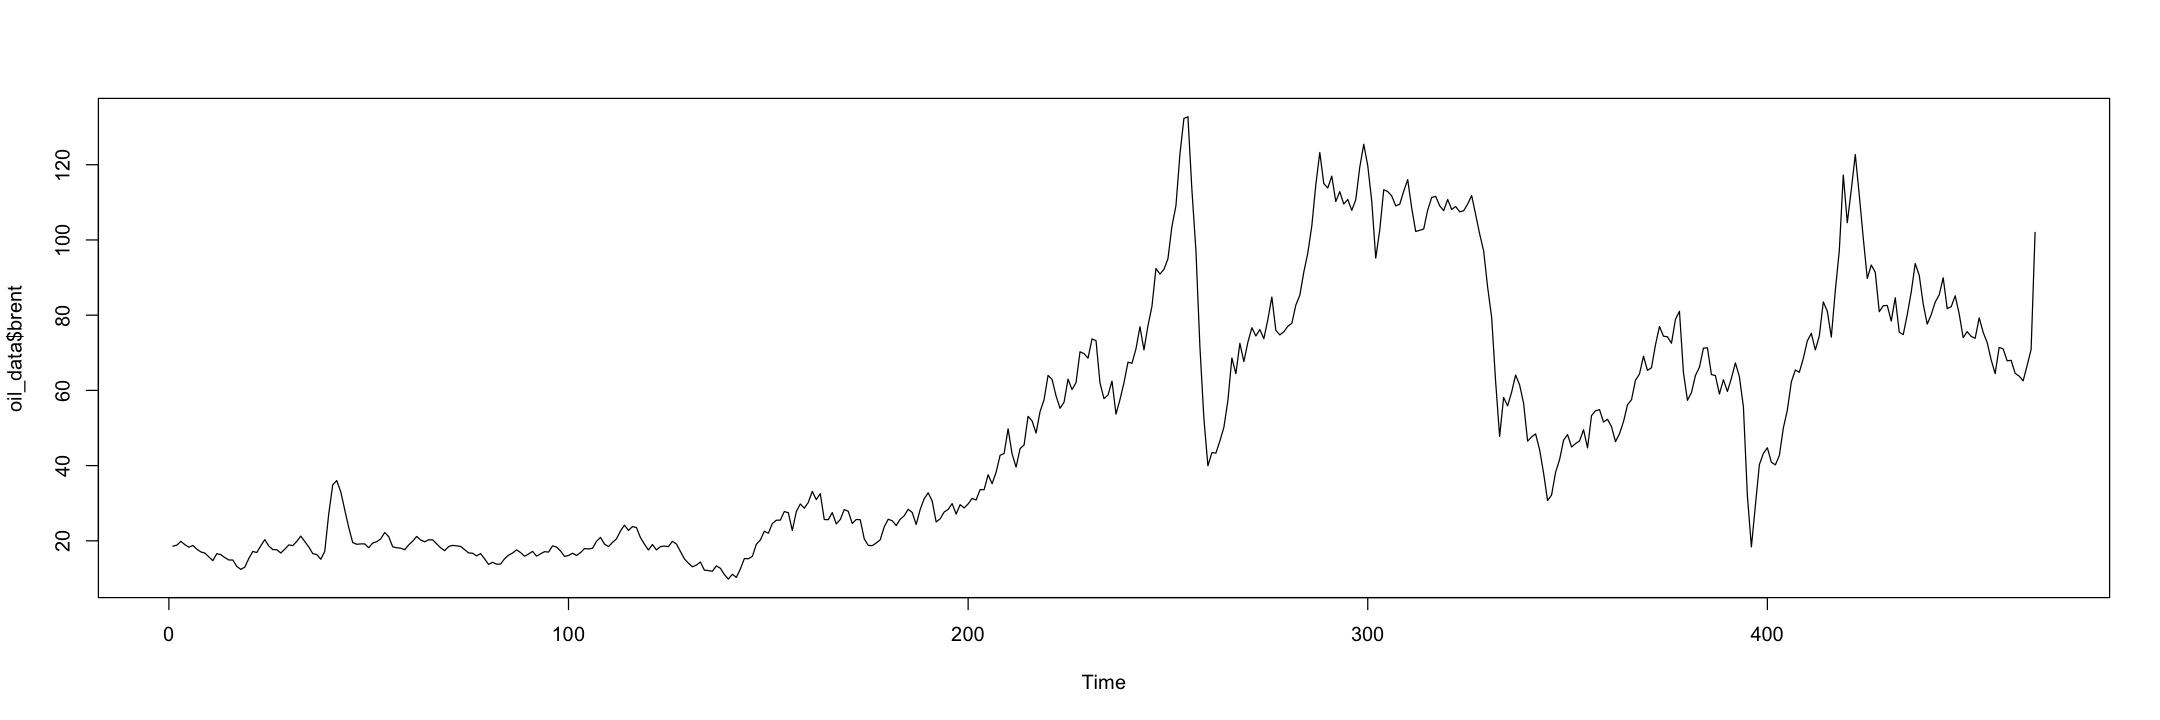

In [6]:
oil_data <- read.csv("brent.csv", stringsAsFactors = FALSE)

oil_data <- oil_data %>%
  mutate(
    date = as.Date(paste0("01-", Month), format = "%d-%b-%y"),
    brent = as.numeric(brent)
  ) %>%
  arrange(date)

range(oil_data$date)
par(mfrow = c(1, 1))
plot.ts(oil_data$brent)

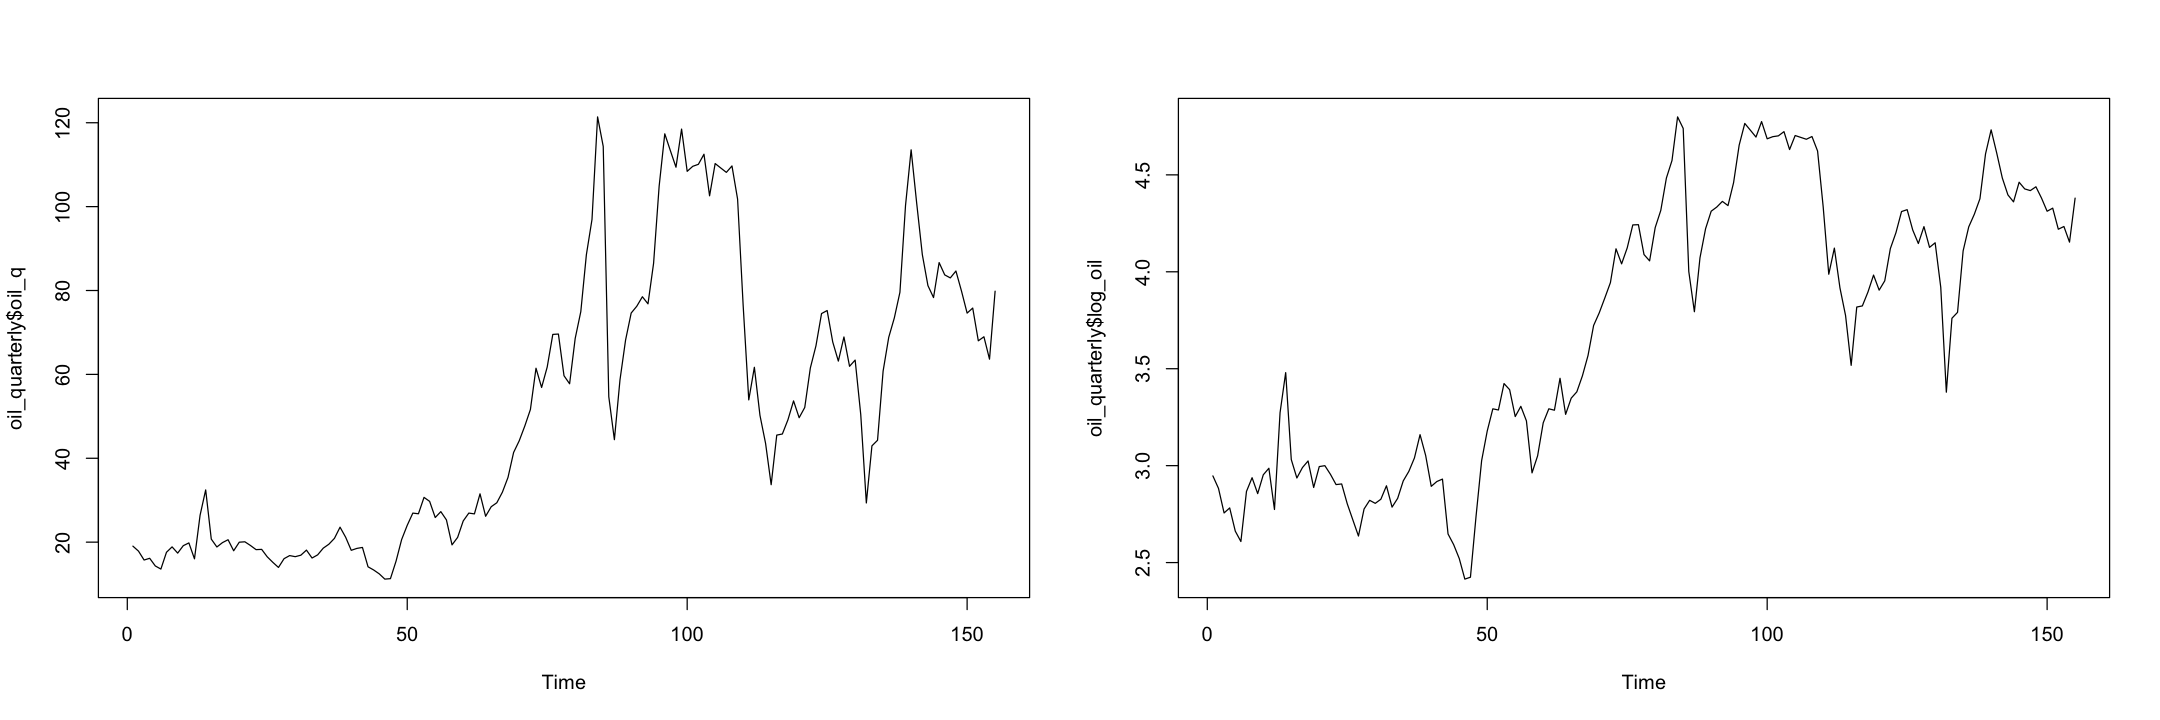

In [7]:
oil_quarterly <- oil_data %>%
  group_by(quarter = floor_date(date, "quarter")) %>%
  summarize(
    oil_q = mean(brent, na.rm = TRUE)
  ) %>% 
  arrange(quarter) %>%
  mutate(
    log_oil = log(oil_q),
    oil_ann = 400 * (log_oil - lag(log_oil, 1))
  ) %>%
  na.omit()


par(mfrow = c(1, 2))
plot.ts(oil_quarterly$oil_q)
plot.ts(oil_quarterly$log_oil)

The data are transformed into annualized quarter-on-quarter first differences

## SHADOW RATE
[Shadow rate from  from Cynthia Wu's website](https://sites.google.com/view/jingcynthiawu/shadow-rates)

[Eonia rate](https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.4F.MM.EONIA.HSTA)

[Short-term rate](https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.4F.MM.UONSTR.HSTA)

As data for the monetary shock, the Eonia rate is used until 2008Q3, then for the period of low interest rates and the ZLB, the values are imputed as the Shadow rate from Cynthia Wu's website until 2022Q2. After the period of Great Inflation arrived, data from the overnight short-term rate are used.

[time]: 'date' [value]: 'rate' 



[1] "1994-01-01" "2026-04-01"

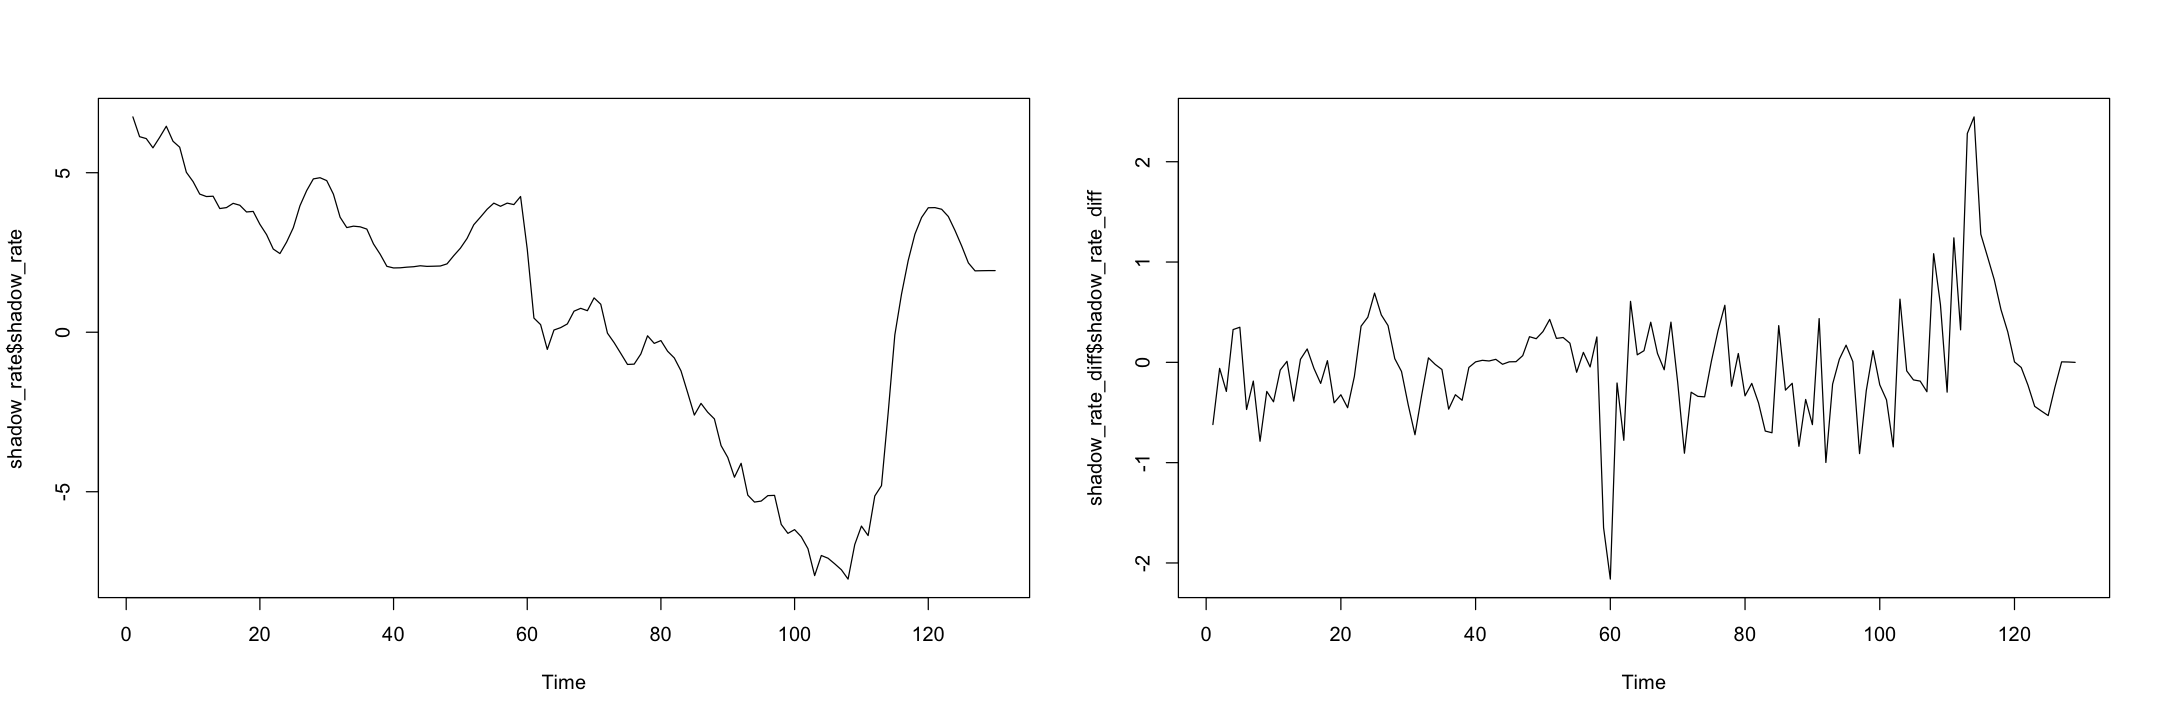

In [8]:
eonia_data <- get_data("FM.M.U2.EUR.4F.MM.EONIA.HSTA") %>%
  dplyr::mutate(date = as.Date(paste0(obstime, "-01"))) %>%
  dplyr::select(date, rate = obsvalue) %>%
  dplyr::arrange(date)

str_data <- get_data("FM.M.U2.EUR.4F.MM.UONSTR.HSTA") %>%
  dplyr::mutate(date = as.Date(paste0(obstime, "-01"))) %>%
  dplyr::select(date, rate = obsvalue) %>%
  dplyr::arrange(date)

combined_actual_rate <- bind_rows(
    eonia_data %>% filter(date < "2019-10-01"),
    str_data %>% filter(date >= "2019-10-01")
  ) %>%
  arrange(date)

quarterly_rate <- combined_actual_rate %>%
  group_by(date = floor_date(date, "quarter")) %>%
  summarize(rate = mean(rate, na.rm = TRUE)) %>%
  arrange(date)

shadow_values <- c(
  2.605, # 2008 Q4
  0.444, 0.238, -0.539, 0.069, # 2009
  0.144, 0.260, 0.660, 0.749,  # 2010
  0.675, 1.076, 0.877, -0.029, # 2011
  -0.327, -0.666, -1.010, -1.000, # 2012
  -0.681, -0.112, -0.350, -0.262, # 2013
  -0.596, -0.806, -1.210, -1.895, # 2014
  -2.597, -2.231, -2.508, -2.717, # 2015
  -3.554, -3.924, -4.545, -4.109, # 2016
  -5.107, -5.324, -5.293, -5.122, # 2017
  -5.114, -6.024, -6.305, -6.188, # 2018
  -6.412, -6.786, -7.629, -6.999, # 2019
  -7.084, -7.259, -7.446, -7.739, # 2020
  -6.656, -6.077, -6.374, -5.133, # 2021
  -4.809, -2.527  # 2022 (to Q2)
)
data_shadow_zlb <- ts(shadow_values, start = c(2008, 4), frequency = 4)
data_shadow_zlb <- ts_xts(data_shadow_zlb)

quarterly_xts <- ts_xts(quarterly_rate)
data_pre2012  <- quarterly_xts["/2008-09"]
data_post2022 <- quarterly_xts["2022-07/"]

shadowrate_final <- rbind(data_pre2012, data_shadow_zlb, data_post2022)

shadow_rate <- ts_df(shadowrate_final) %>% 
  rename(date = time, shadow_rate = value)

shadow_rate_diff <- shadow_rate %>%
  mutate(
    shadow_rate_diff = shadow_rate - lag(shadow_rate),
  ) %>%
  na.omit()

range(shadow_rate$date)
par(mfrow = c(1, 2))
plot.ts(shadow_rate$shadow_rate)
plot.ts(shadow_rate_diff$shadow_rate_diff)

In [9]:
adf.test(shadow_rate$shadow_rate)


	Augmented Dickey-Fuller Test

data:  shadow_rate$shadow_rate
Dickey-Fuller = -2.418, Lag order = 5, p-value = 0.4027
alternative hypothesis: stationary


Same as in stage 2, I'll use the data in levels. 

## Real Gross Domestic Product for Germany 
(NGDPRSAXDCDEQ)

Source: FRED / IMF

Units: Millions of Domestic Currency,
Seasonally Adjusted

Frequency: Quarterly

[1] "1991-01-01" "2025-10-01"

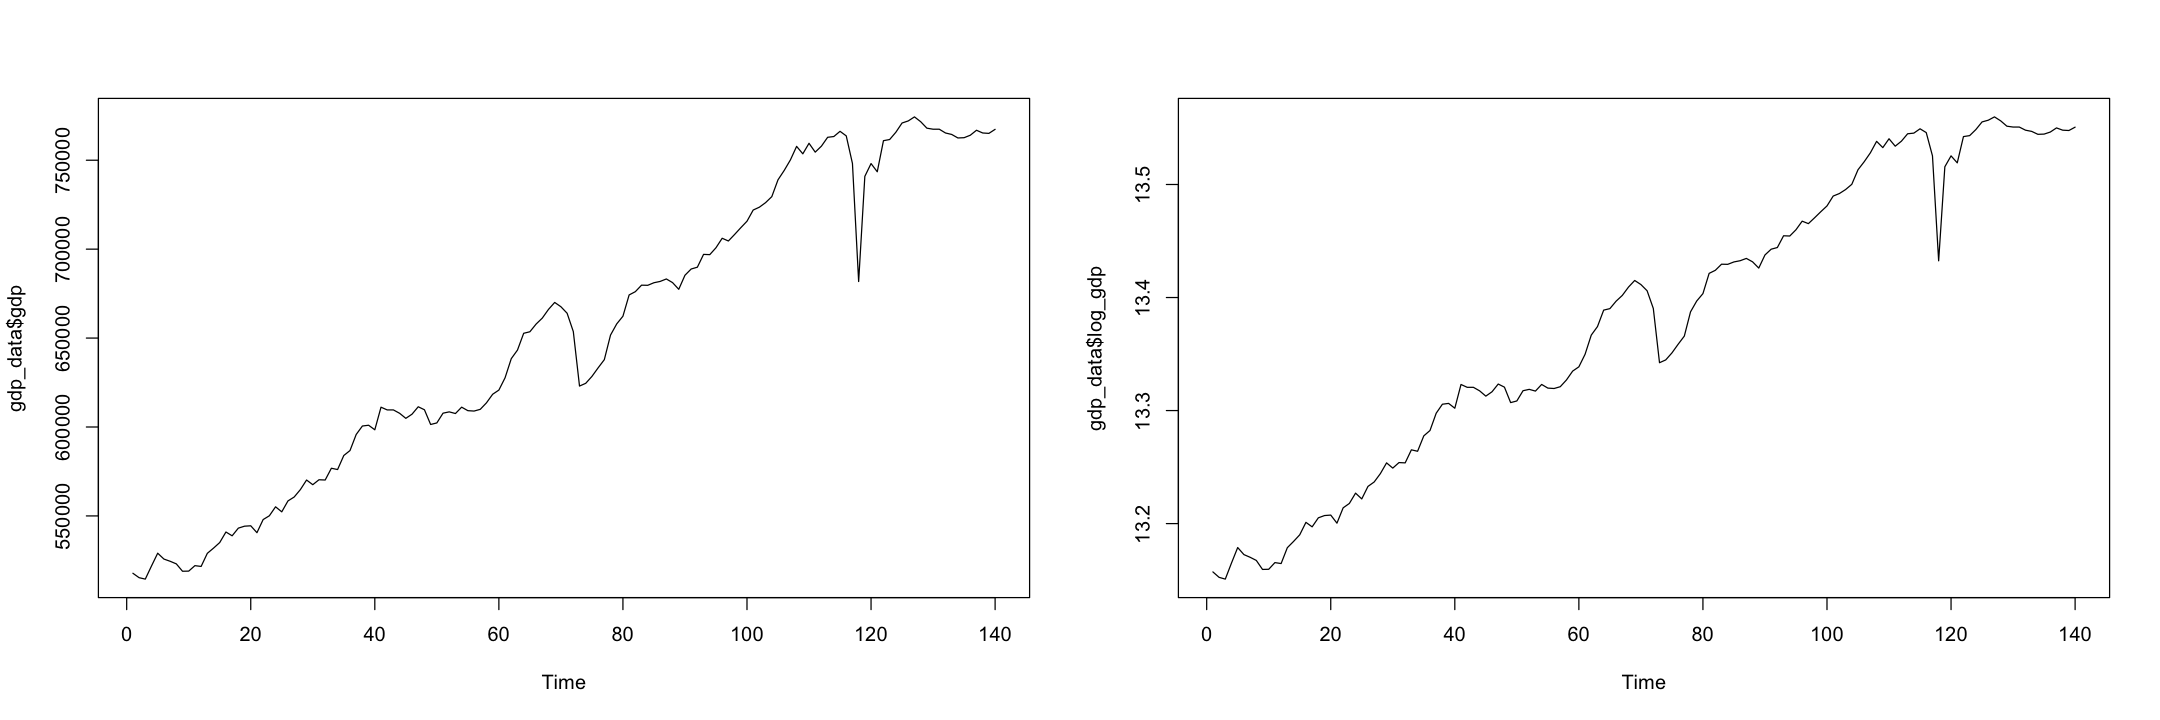

In [10]:
fredr_set_key(fred_key)
gdp_data <- fredr(
    series_id = "NGDPRSAXDCDEQ",
    observation_start = as.Date("1991-01-01"),
    frequency = "q"
) %>%
  dplyr::select(date, gdp = value) %>%
  dplyr::arrange(date)

range(gdp_data$date)

par(mfrow = c(1, 2))
plot.ts(gdp_data$gdp)

gdp_data <- gdp_data %>% 
  mutate(log_gdp = log(gdp),
         gdp_ann = 400 * (log_gdp - lag(log_gdp, 1))
         )
plot.ts(gdp_data$log_gdp)

## HICP Inflation rate 
(HICP.M.DE.N.000000.4D0.INX)
Source: ECB Data Portal / Eurostat

Units:  Index,
Not Seasonally Adjusted

Frequency: Monthly

[1] "1996-01-01" "2026-04-01"

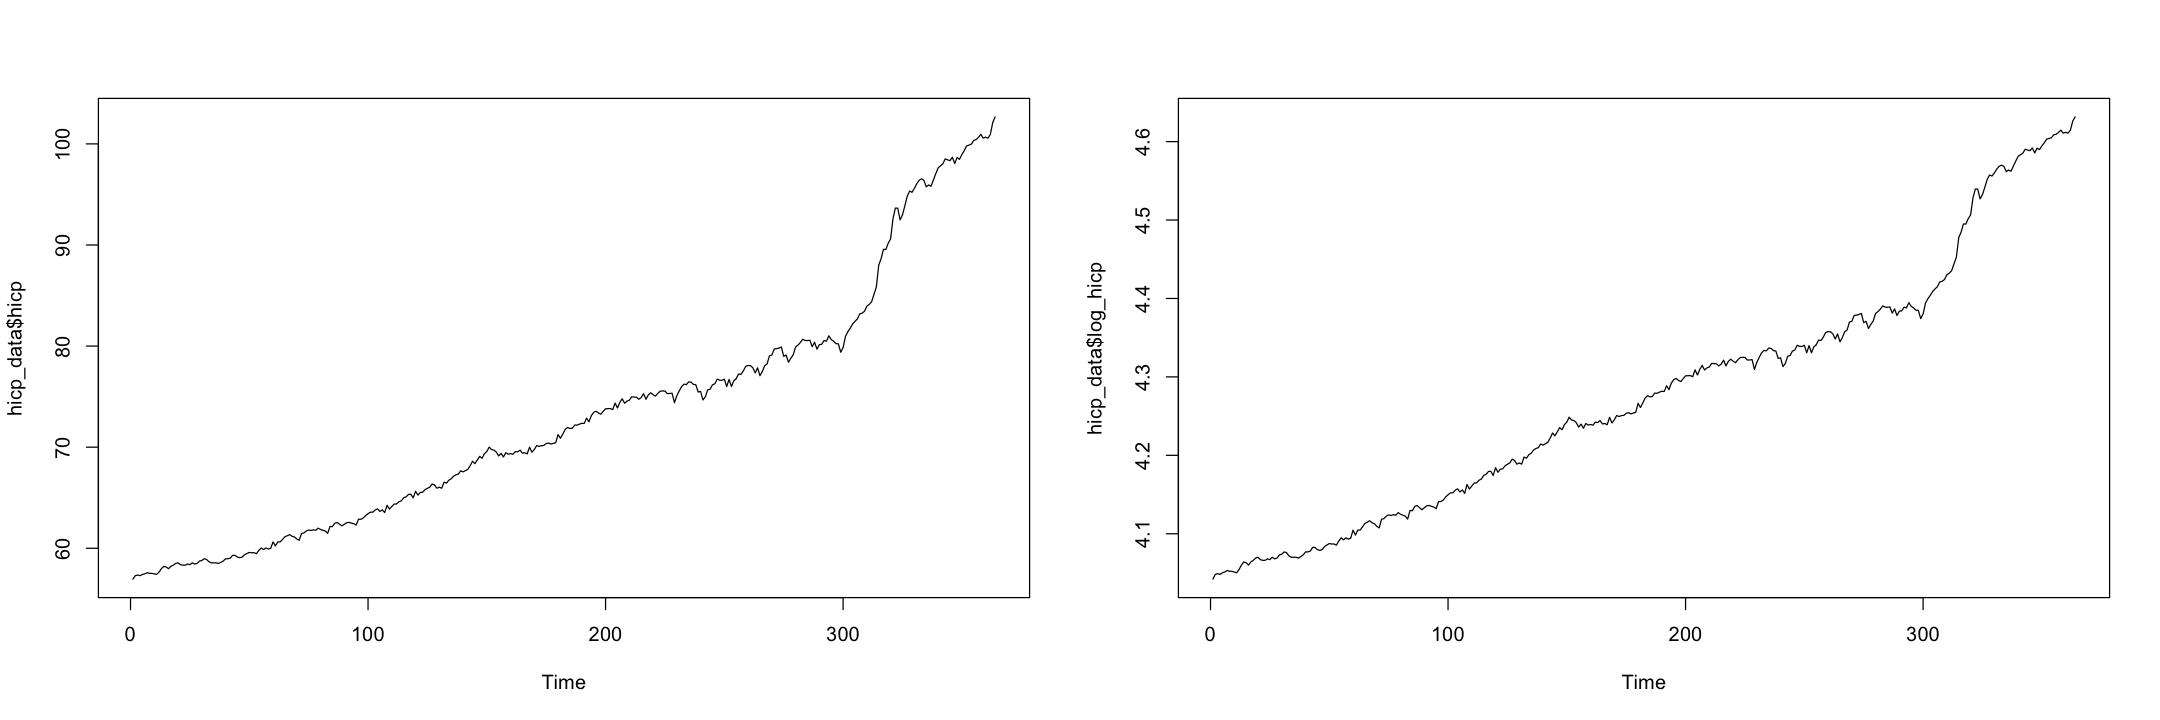

In [11]:
hicp_data <- get_data("HICP.M.DE.N.000000.4D0.INX") %>%
  dplyr::mutate(date = as.Date(paste0(obstime, "-01"))) %>%
  dplyr::select(date, hicp = obsvalue) %>%
  dplyr::arrange(date)

range(hicp_data$date)
par(mfrow = c(1, 2))

hicp_data <- hicp_data %>% 
  mutate(log_hicp = log(hicp))


plot.ts(hicp_data$hicp)
plot.ts(hicp_data$log_hicp)

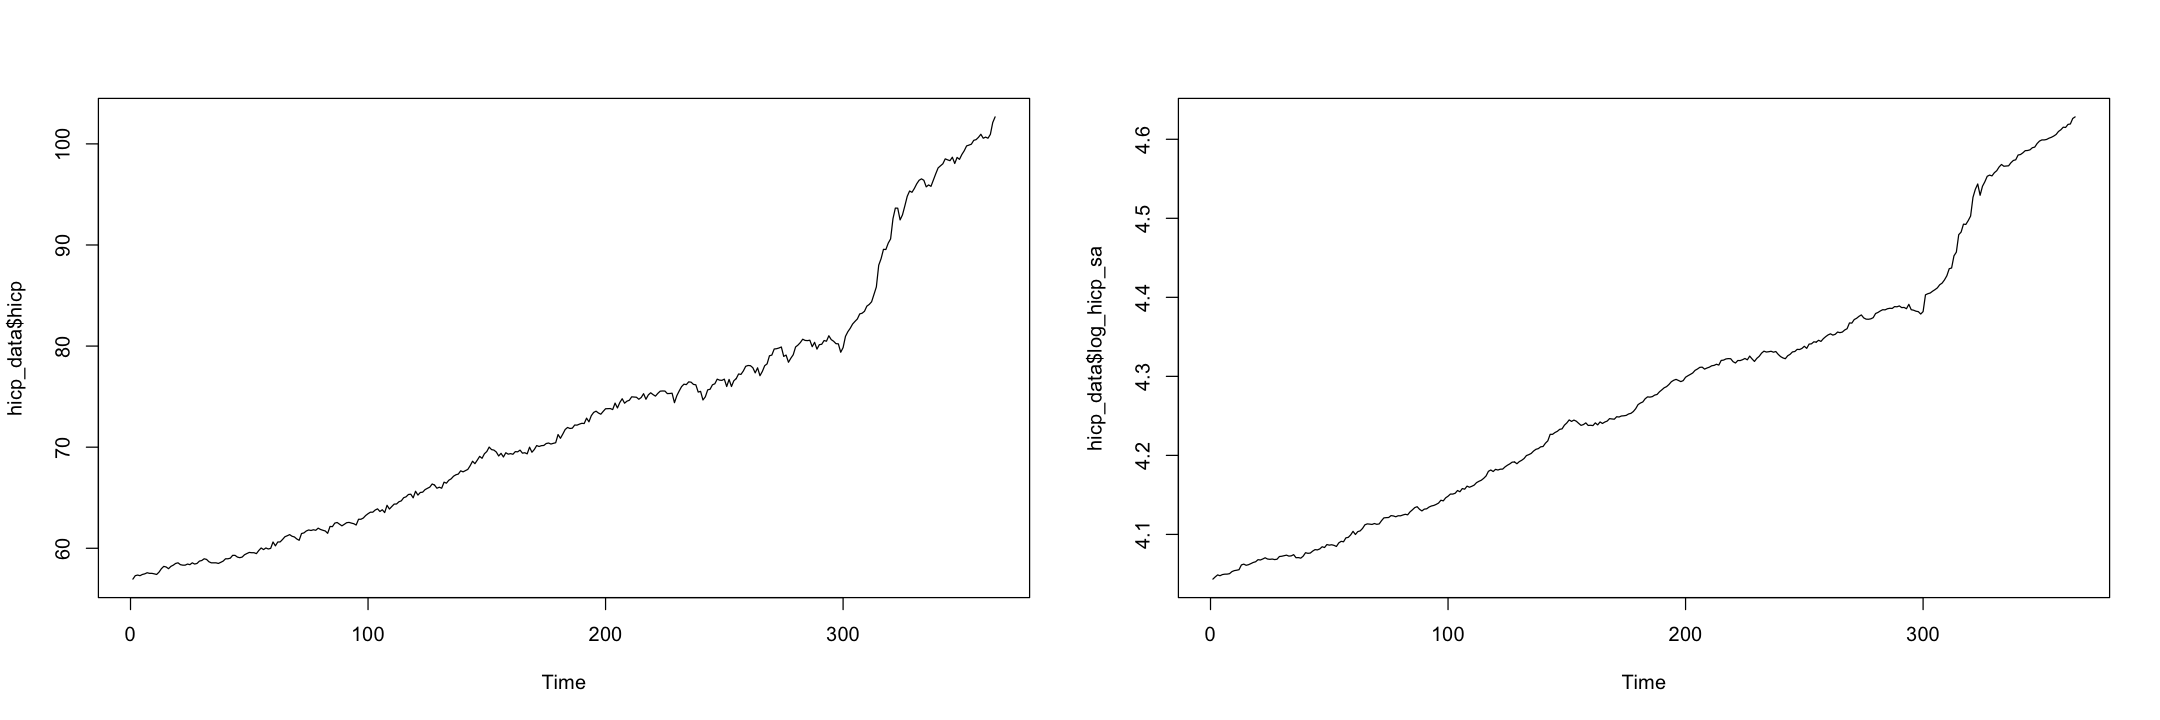

In [12]:
# seasonallity adjustment
log_hicp_ts <- ts(hicp_data$log_hicp, start = c(1996, 1), frequency = 12)
tramo_m_model <- tramoseats(log_hicp_ts, spec = "RSAfull")
hicp_data$log_hicp_sa <- as.numeric(tramo_m_model$final$series[, "sa"])

#plots
par(mfrow = c(1, 2))
plot.ts(hicp_data$hicp)
plot.ts(hicp_data$log_hicp_sa)

# MERGE

In [13]:
data <- gdp_data %>%
  inner_join(oil_quarterly %>% rename(date = quarter), by = "date") %>%
  inner_join(hicp_data, by = "date") %>%
  inner_join(shadow_rate, by = "date") %>%
  dplyr::select(
    date, 
    oil = log_oil,
    gdp = log_gdp, 
    hicp = log_hicp_sa, 
    rate = shadow_rate,
  ) %>%
  na.omit()

head(data,2)
tail(data,2)

date,oil,gdp,hicp,rate
<date>,<dbl>,<dbl>,<dbl>,<dbl>
1996-01-01,2.921368,13.20039,4.043437,5.013333
1996-04-01,2.970585,13.21396,4.047729,4.723333


date,oil,gdp,hicp,rate
<date>,<dbl>,<dbl>,<dbl>,<dbl>
2025-07-01,4.233623,13.54776,4.604079,1.923617
2025-10-01,4.153033,13.55072,4.612040,1.928417


# 1). VAR model in levels

In [14]:
vardata1 <- data[,c("oil","gdp", "hicp", "rate")]

In [15]:
var1.select <- VARselect(vardata1, lag.max=8, type ="const")
var1.select$selection

AIC(n)  HQ(n)  SC(n) FPE(n) 
     3      2      2      3

The VARselect function suggests 2 or 3 lags. I will start with 2 lags, but first, I have to check the residuals

In [16]:
model1 <- VAR(vardata1, p = 2, type = "const")
test <- serial.test(model1)
test$serial

model2 <- VAR(vardata1, p = 3, type = "const")
test <- serial.test(model2)
test$serial

model3 <- VAR(vardata1, p = 4, type = "both")
test <- serial.test(model3)
test$serial

model4 <- VAR(vardata1, p = 5, type = "const")
test <- serial.test(model4)
test$serial


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model1
Chi-squared = 267.18, df = 224, p-value = 0.0254



	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model2
Chi-squared = 232.93, df = 208, p-value = 0.1134



	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model3
Chi-squared = 220.63, df = 192, p-value = 0.07671



	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model4
Chi-squared = 216.58, df = 176, p-value = 0.02013


If I use 2 lags, the test shows there is still some information left in the residuals. For 3 and 4 lags, the model already passes the null hypothesis. To make the results easier to interpret for quarterly data (covering 1 year back), I will use the model with 4 lags.

### Model estimation

In [17]:
summary(model3)


VAR Estimation Results:
Endogenous variables: oil, gdp, hicp, rate 
Deterministic variables: both 
Sample size: 116 
Log Likelihood: 843.113 
Roots of the characteristic polynomial:
0.9839 0.9297 0.8359 0.8359 0.7257 0.7257 0.6559 0.6559 0.6392 0.5964 0.5964 0.5359 0.5359 0.4754 0.2623 0.2623
Call:
VAR(y = vardata1, p = 4, type = "both")


Estimation results for equation oil: 
oil = oil.l1 + gdp.l1 + hicp.l1 + rate.l1 + oil.l2 + gdp.l2 + hicp.l2 + rate.l2 + oil.l3 + gdp.l3 + hicp.l3 + rate.l3 + oil.l4 + gdp.l4 + hicp.l4 + rate.l4 + const + trend 

         Estimate Std. Error t value Pr(>|t|)    
oil.l1   1.236970   0.118826  10.410  < 2e-16 ***
gdp.l1  -2.563329   1.197695  -2.140 0.034819 *  
hicp.l1 -6.119364   3.143542  -1.947 0.054440 .  
rate.l1 -0.020541   0.037694  -0.545 0.587035    
oil.l2  -0.379424   0.174331  -2.176 0.031923 *  
gdp.l2   2.061675   1.498221   1.376 0.171933    
hicp.l2  6.422605   4.425530   1.451 0.149900    
rate.l2  0.019750   0.053822   0.367 0.714442

I had to use type 'both' instead of 'const' to keep root under 1.0

## IRF'S 

### IRF for oil shock

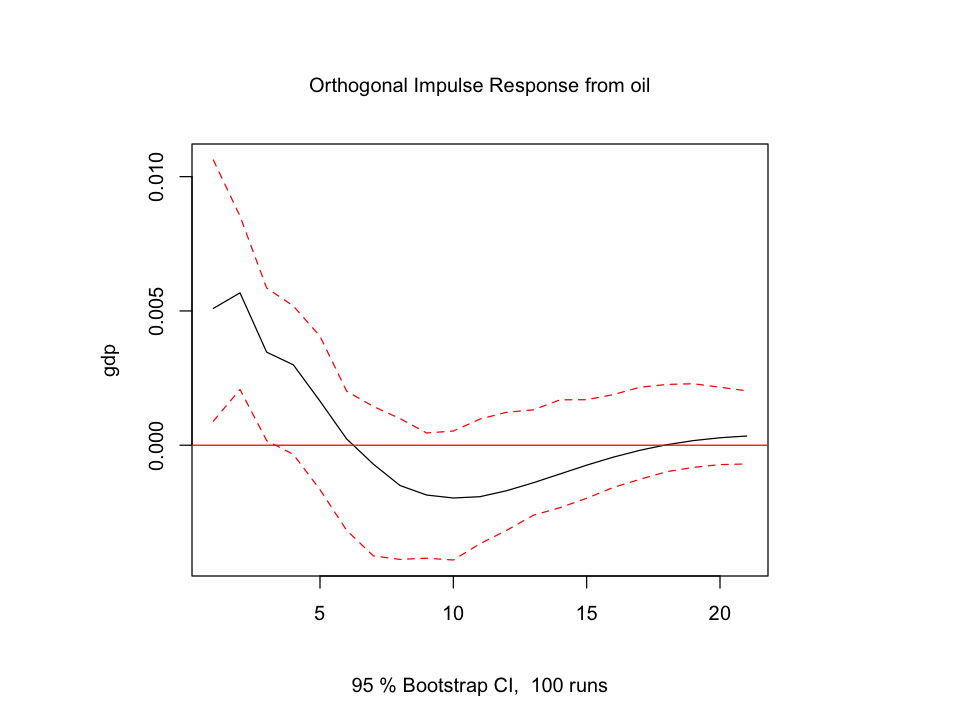

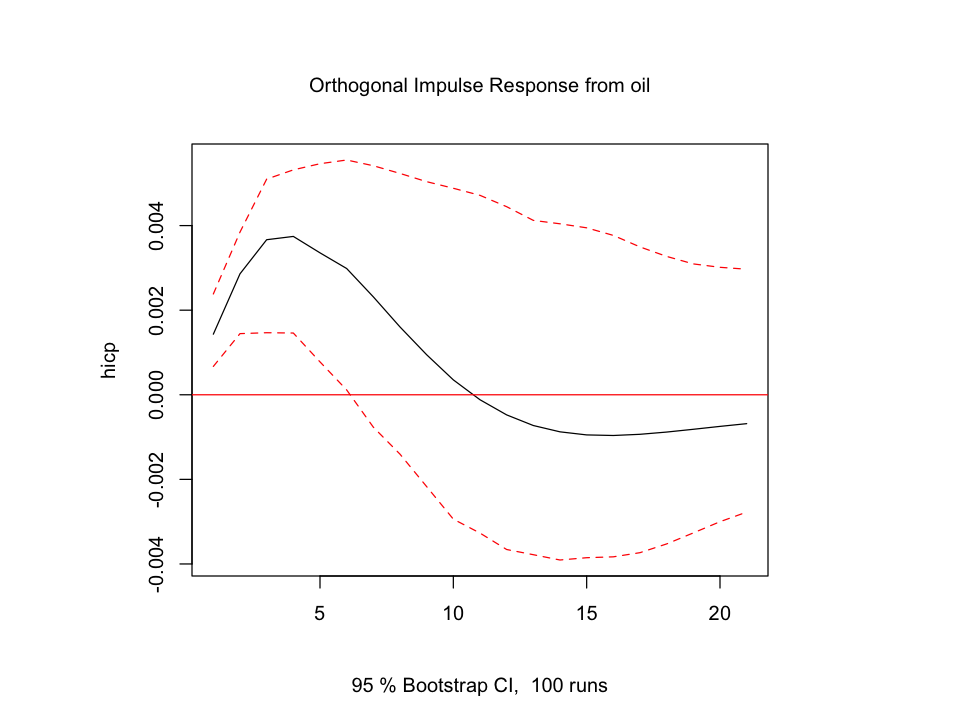

In [18]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(vars::irf(model3,impulse = "oil", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(vars::irf(model3,impulse = "oil", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

An oil price shock initially has a positive effect on GDP, which subsequently fades out and the level of gdp stable.  Economic intuition would suggest the opposite, as Germany is heavily dependent on energy imports. On the other hand oil shock has a statistical positive effect on inflation in first 2 years. It suggest permanent increase of price level with no statistical significance

### IRF for interest rate shock

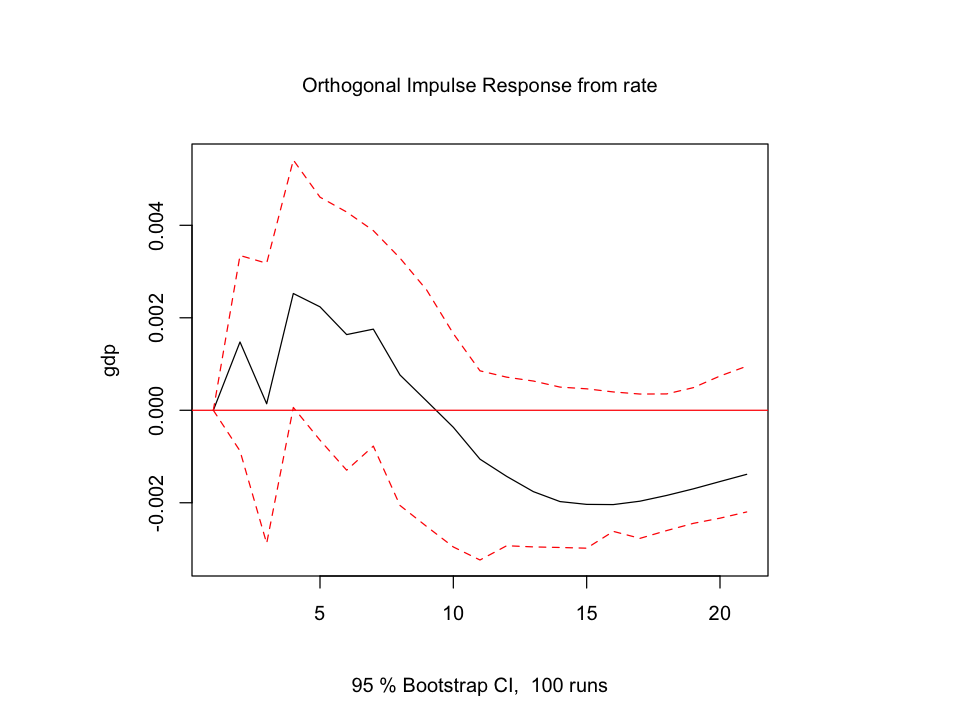

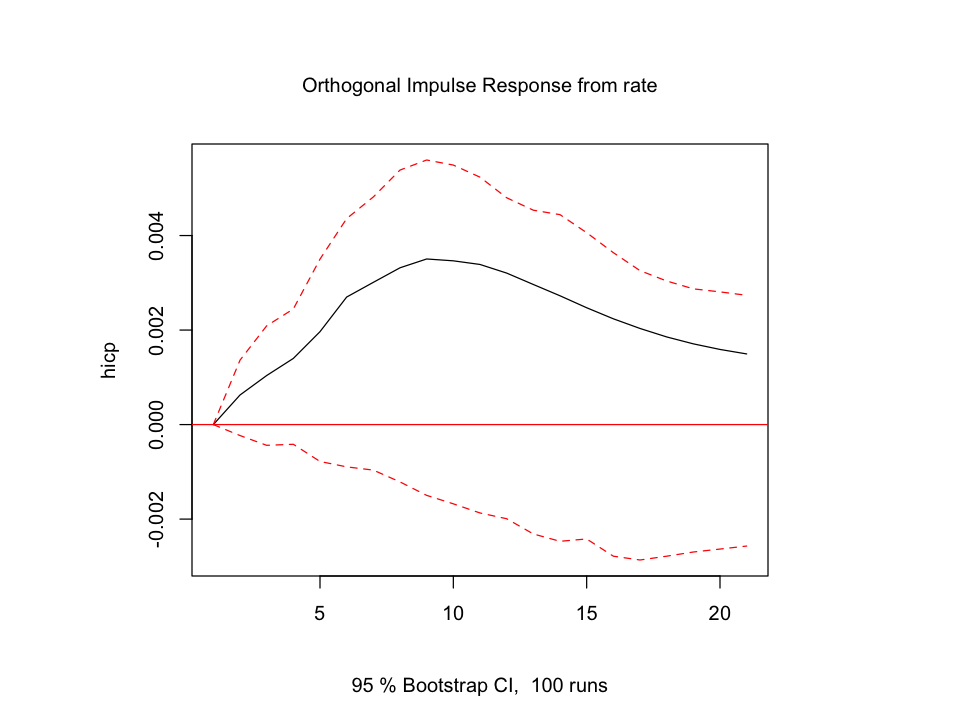

In [19]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(vars::irf(model3,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(vars::irf(model3,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

For the interest rate shock's impact on inflation, we can observe a price puzzle that lacks statistical significance. Regarding GDP, a statistically significant decline in the GDP level is visible over the medium-term horizon. 

Overall, it is evident that the shocks have a permanent effect. We observe a loss of efficiency compared to the standard VAR, as evidenced by the wider confidence intervals.

## Forecast

In [20]:
predict(model3, n.ahead = 12, ci = 0.95)

$oil
          fcst    lower    upper        CI
 [1,] 4.035738 3.747506 4.323970 0.2882318
 [2,] 3.988089 3.559034 4.417143 0.4290542
 [3,] 3.961904 3.460947 4.462862 0.5009575
 [4,] 3.935358 3.384632 4.486085 0.5507264
 [5,] 3.918166 3.324409 4.511924 0.5937575
 [6,] 3.898061 3.268369 4.527753 0.6296919
 [7,] 3.881699 3.216538 4.546860 0.6651610
 [8,] 3.864778 3.167769 4.561786 0.6970086
 [9,] 3.846927 3.120403 4.573450 0.7265237
[10,] 3.827881 3.075156 4.580606 0.7527249
[11,] 3.808188 3.032715 4.583660 0.7754726
[12,] 3.787950 2.992431 4.583469 0.7955189

$gdp
          fcst    lower    upper         CI
 [1,] 13.54928 13.52324 13.57531 0.02603587
 [2,] 13.55027 13.51783 13.58271 0.03244431
 [3,] 13.55307 13.51783 13.58831 0.03524005
 [4,] 13.55586 13.51761 13.59411 0.03825213
 [5,] 13.55915 13.51996 13.59834 0.03919096
 [6,] 13.56253 13.52274 13.60232 0.03978982
 [7,] 13.56601 13.52562 13.60639 0.04038166
 [8,] 13.56917 13.52839 13.60996 0.04078159
 [9,] 13.57222 13.53094 13.61350 0

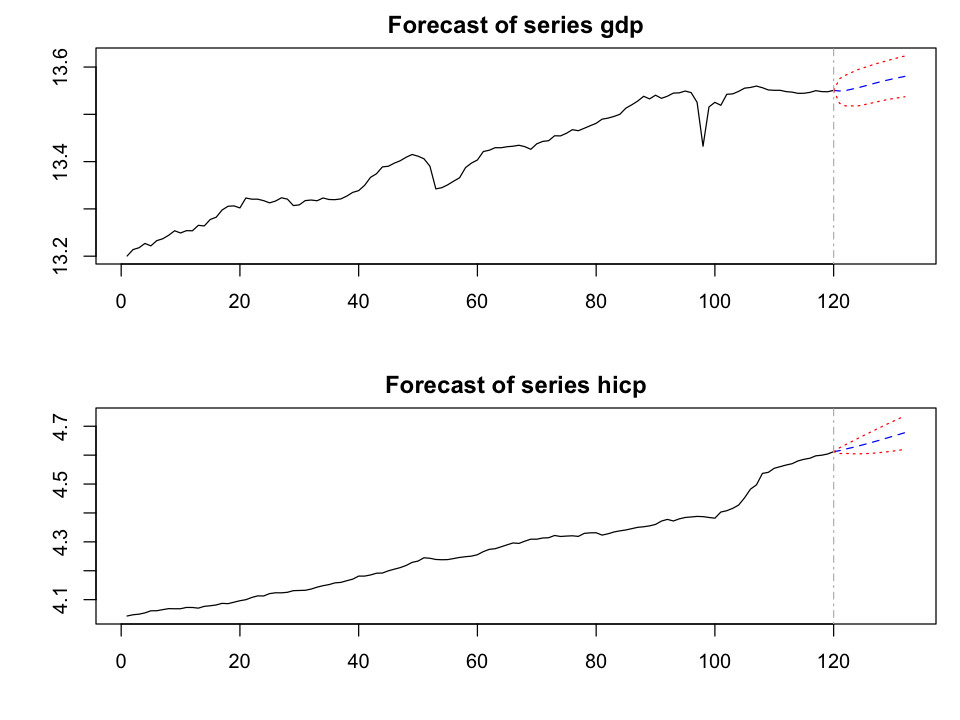

In [21]:
forecast <- predict(model3, n.ahead = 12, ci = 0.95)
par(mfrow = c(1, 2), mar = c(4, 4, 2, 1))
plot(forecast, names = c("gdp", "hicp"))

In [ ]:
We can see forecast which follows the trend.

# 2. VECM

### Johansen procedure

I use the Johansen trace test to check for cointegration,

In [62]:
coint_var1 <- ca.jo(vardata1, type="trace", ecdet = "trend", K = 4)
summary(coint_var1)


###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , with linear trend in cointegration 

Eigenvalues (lambda):
[1]  1.859129e-01  1.511368e-01  4.369124e-02  2.532167e-02 -3.122502e-17

Values of teststatistic and critical values of test:

          test 10pct  5pct  1pct
r <= 3 |  2.98 10.49 12.25 16.26
r <= 2 |  8.16 22.76 25.32 30.45
r <= 1 | 27.16 39.06 42.44 48.45
r = 0  | 51.02 59.14 62.99 70.05

Eigenvectors, normalised to first column:
(These are the cointegration relations)

             oil.l4     gdp.l4       hicp.l4     rate.l4     trend.l4
oil.l4    1.0000000  1.0000000   1.000000000   1.0000000   1.00000000
gdp.l4   49.6113205 -2.9655764 -11.872583797 -40.0108832   0.42635256
hicp.l4  46.7437136 52.7872224   6.545647579 -26.1502700 -21.62140640
rate.l4  -0.1991702 -0.6085935  -0.076994482   0.4924867   0.04239929
trend.l4 -0.3735285 -0.2798929   0.008521703   0.2350042   0.07483695

Weights W:
(This is the loading matrix)

Trace test indicate just one cointegrating vector (same for eigen but i deleted it)

In [63]:
cajorls_var1 <- cajorls(coint_var1, r=1)
summary(cajorls_var1$rlm)

Response oil.d :

Call:
lm(formula = oil.d ~ ect1 + constant + oil.dl1 + gdp.dl1 + hicp.dl1 + 
    rate.dl1 + oil.dl2 + gdp.dl2 + hicp.dl2 + rate.dl2 + oil.dl3 + 
    gdp.dl3 + hicp.dl3 + rate.dl3 - 1, data = data.mat)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.56336 -0.07539  0.01213  0.08469  0.32674 

Coefficients:
         Estimate Std. Error t value Pr(>|t|)    
ect1     -0.06446    0.01588  -4.060 9.66e-05 ***
constant 54.59000   13.43528   4.063 9.53e-05 ***
oil.dl1   0.28945    0.11445   2.529   0.0130 *  
gdp.dl1  -2.74539    1.17887  -2.329   0.0218 *  
hicp.dl1 -5.73513    3.03846  -1.888   0.0619 .  
rate.dl1 -0.03926    0.03568  -1.100   0.2738    
oil.dl2  -0.09337    0.11931  -0.783   0.4357    
gdp.dl2  -0.68674    1.24579  -0.551   0.5827    
hicp.dl2  1.52296    3.11284   0.489   0.6257    
rate.dl2 -0.01156    0.03514  -0.329   0.7428    
oil.dl3  -0.06350    0.11075  -0.573   0.5676    
gdp.dl3  -2.98499    1.26867  -2.353   0.0205 *  
hicp.dl3  1.

## IRF's for VECM

In [64]:
vecm_var1 <- vec2var(coint_var1, r=1)

### IRF for oil shock

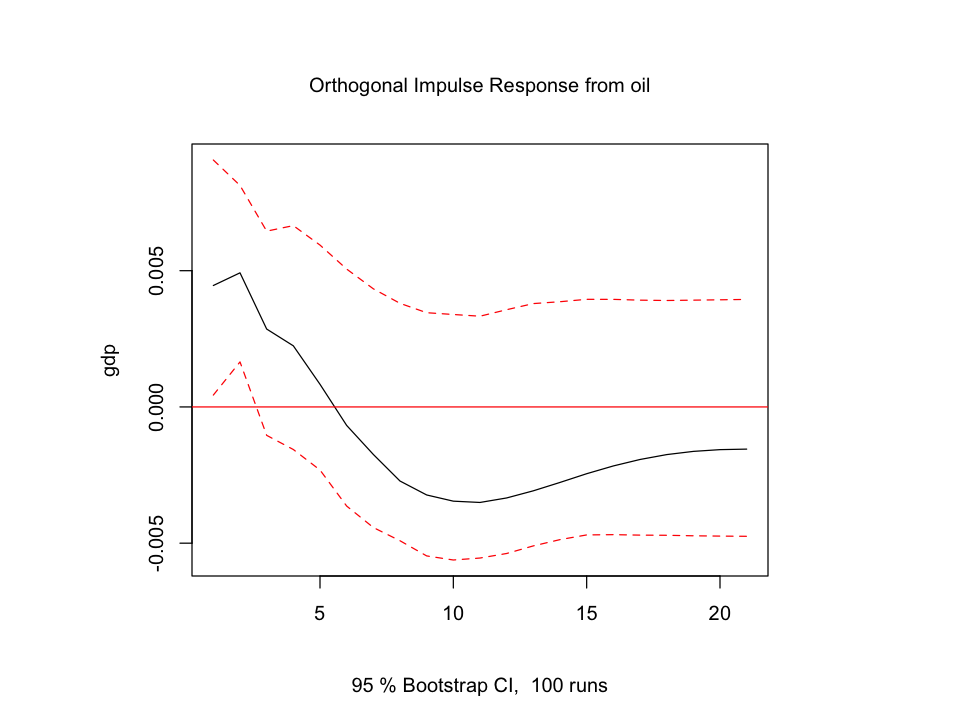

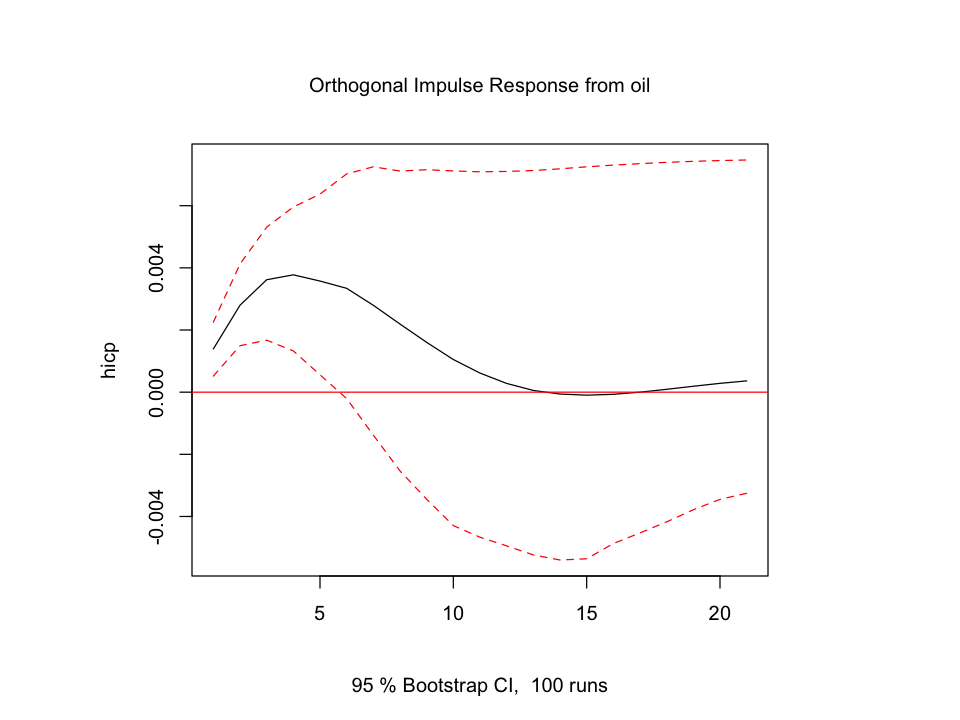

In [65]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(vars::irf(vecm_var1,impulse = "oil", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(vars::irf(vecm_var1,impulse = "oil", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

Once again, we observe a positive and statistically significant impact of the oil shock on both GDP and HICP. Compared to the VAR in levels, the trajectory is considerably smoother, providing a better estimation of long-term structural relationships and trending towards a sustained increase in levels.

### IRF for interest rate shock

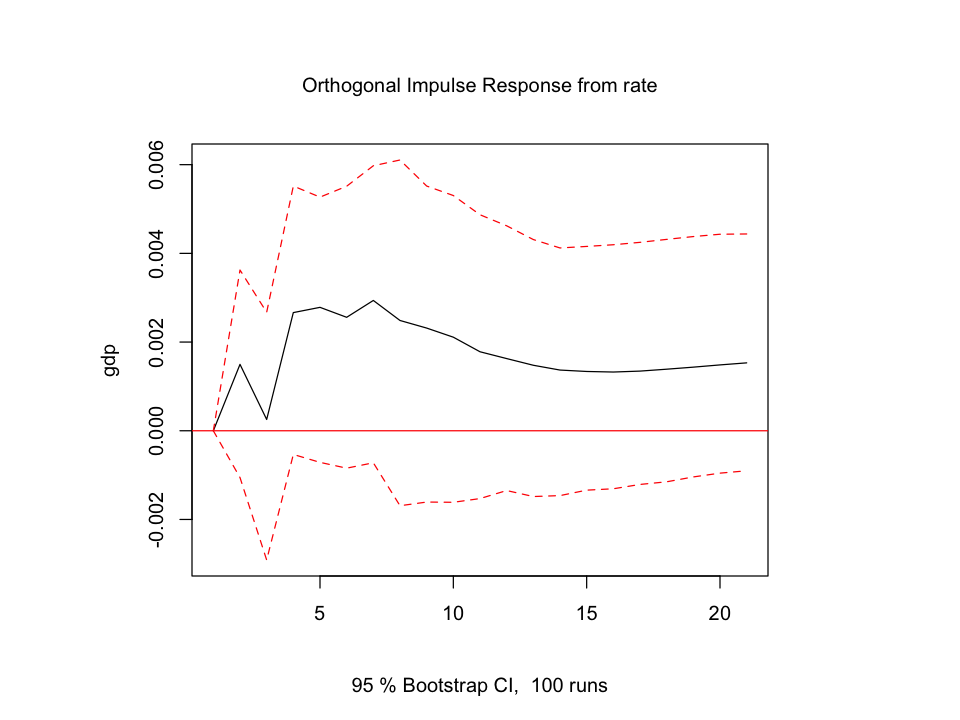

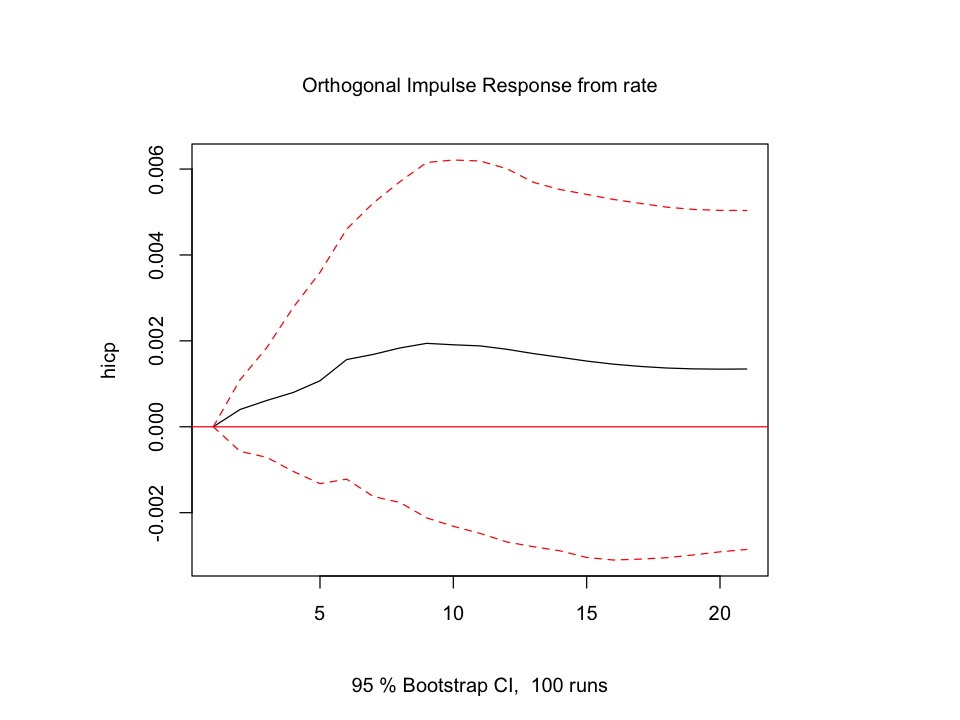

In [53]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(vars::irf(vecm_var1,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(vars::irf(vecm_var1,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

Similar to the VAR in levels, the effect is not statistically significant. However, we observe a permanent shift in the levels

## Forecast

In [47]:
vecm1irf <- vars::irf(vecm_var1, n.ahead = 20)
predict(vecm_var1)

$oil
          fcst    lower    upper        CI
 [1,] 4.100242 3.807694 4.392790 0.2925478
 [2,] 4.100490 3.633271 4.567709 0.4672192
 [3,] 4.101007 3.516962 4.685052 0.5840449
 [4,] 4.103521 3.428244 4.778798 0.6752768
 [5,] 4.107293 3.354471 4.860115 0.7528218
 [6,] 4.112789 3.287845 4.937734 0.8249447
 [7,] 4.117260 3.226898 5.007622 0.8903624
 [8,] 4.120792 3.170267 5.071316 0.9505243
 [9,] 4.125280 3.117639 5.132920 1.0076405
[10,] 4.129033 3.067418 5.190649 1.0616155

$gdp
          fcst    lower    upper         CI
 [1,] 13.55302 13.52712 13.57892 0.02589922
 [2,] 13.55559 13.52012 13.59107 0.03547661
 [3,] 13.55774 13.51586 13.59961 0.04187790
 [4,] 13.56100 13.51167 13.61033 0.04933271
 [5,] 13.56393 13.50929 13.61856 0.05463385
 [6,] 13.56687 13.50722 13.62651 0.05964612
 [7,] 13.57003 13.50551 13.63456 0.06452193
 [8,] 13.57292 13.50407 13.64176 0.06884322
 [9,] 13.57592 13.50279 13.64905 0.07312760
[10,] 13.57892 13.50166 13.65618 0.07725775

$hicp
          fcst    lower  

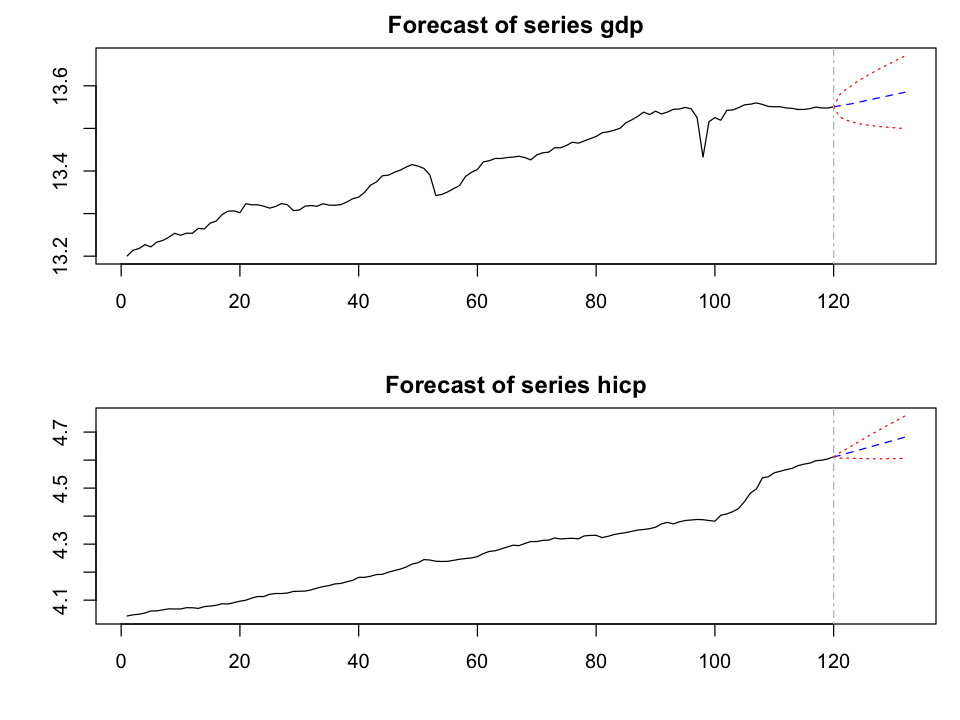

In [48]:
forecast <- predict(vecm_var1, n.ahead = 12, ci = 0.95)
par(mfrow = c(1, 2), mar = c(4, 4, 2, 1))
plot(forecast, names = c("gdp", "hicp"))

The forecasts between the VAR in levels and the VECM are similar. However, upon examining the data, it is evident that the confidence intervals are narrower for the VAR in levels. Personally, I would have expected the opposite since the VECM accounts for long-run equilibrium, but it is likely that the VAR in levels is prone to overfitting.

## Part II: Bayesian VAR and sign restrictions

# Data preparation from stage 2

#### Transformation – HICP

In [66]:
options(repr.plot.width = 18, repr.plot.height = 6)

[1] "1996-01-01" "2026-04-01"

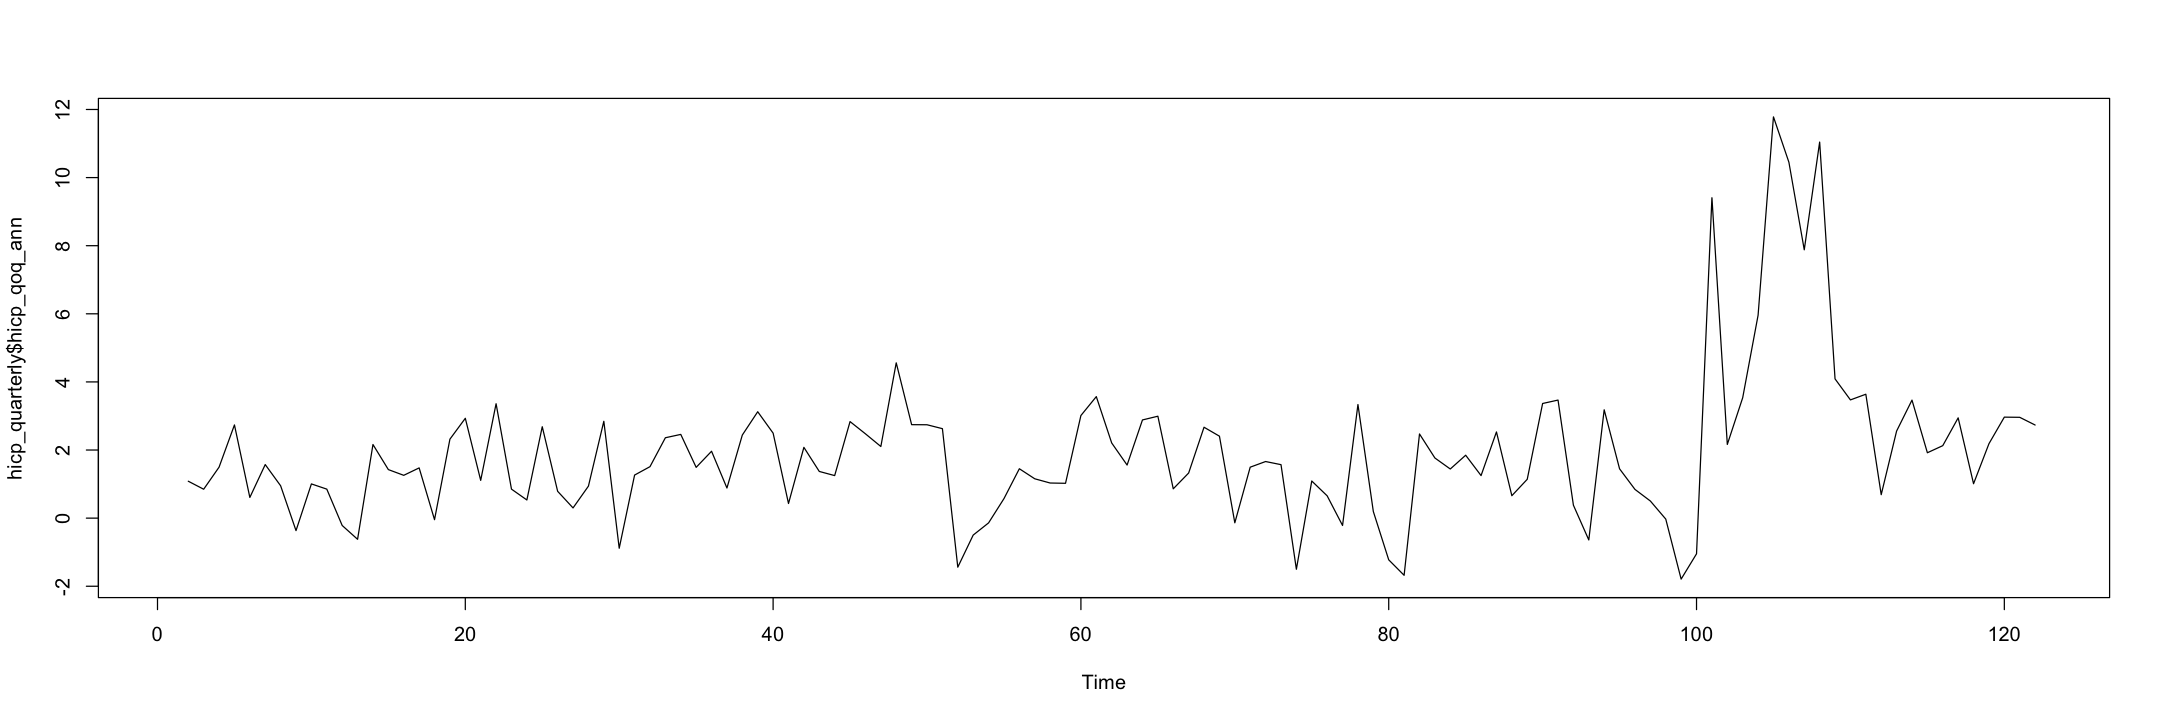

In [67]:
hicp_quarterly <- hicp_data %>%
  group_by(quarter = floor_date(date, "quarter")) %>%
  summarize(
    log_hicp_sa_q = mean(log_hicp_sa, na.rm = TRUE)
  ) %>%
  mutate(
    hicp_qoq_ann = 400*(log_hicp_sa_q - lag(log_hicp_sa_q, 1))
  )
range(hicp_quarterly$quarter)
par(mfrow = c(1,1))
plot.ts(hicp_quarterly$hicp_qoq_ann)

# Merge

In [68]:
data_bvar <- gdp_data %>%
  inner_join(oil_quarterly %>% rename(date = quarter), by = "date") %>%
  inner_join(hicp_quarterly %>% rename(date = quarter), by = "date") %>%
  inner_join(shadow_rate, by = "date") %>%
  dplyr::select(
    date, 
    oil = oil_ann,
    gdp = gdp_ann, 
    hicp = hicp_qoq_ann, 
    rate = shadow_rate,
  ) %>%
  na.omit()

head(data_bvar,2)
tail(data_bvar,2)

date,oil,gdp,hicp,rate
<date>,<dbl>,<dbl>,<dbl>,<dbl>
1996-04-01,19.68701,5.427645,1.0838872,4.723333
1996-07-01,27.72930,1.544912,0.8488372,4.330000


date,oil,gdp,hicp,rate
<date>,<dbl>,<dbl>,<dbl>,<dbl>
2025-07-01,5.607023,-0.11466,2.184700,1.923617
2025-10-01,-32.236251,1.18338,2.965861,1.928417


In stage 2 i used VAR model with 4 lags transformed into annualized quarter-on-quarter first differences (oil, gdp, inflation)

# 3. BVAR

In [137]:
bvardata1 <- data_bvar[,c("oil","gdp", "hicp", "rate")]

since ihave stationary data i have to set b=0, the the package stes lambda and alpha and use Minnesota
prior with a hierarchical prior

In [160]:
prior_bvar <- bv_priors(mn = bv_mn(b=0)) #sets the prior on coefficients to zero since our variables are stationary

In [169]:
bvar1 <- bvar(bvardata1, priors = prior_bvar, lags = 4, n_draw = 10000L, n_burn = 1000L, n_thin = 1L, verbose = FALSE) #verbose = FALSE is used to supress the progress bar from exported output
summary(bvar1)
print(bvar1)

Bayesian VAR consisting of 115 observations, 4 variables and 4 lags.
Time spent calculating: 5.16 secs
Hyperparameters: lambda 
Hyperparameter values after optimisation: 0.29163
Iterations (burnt / thinning): 10000 (1000 / 1)
Accepted draws (rate): 7929 (0.881)

Numeric array (dimensions 17, 4) of coefficient values from a BVAR.
Median values:
             oil    gdp   hicp   rate
constant  15.770  2.896  0.684 -0.305
oil-lag1   0.340  0.023 -0.001  0.002
gdp-lag1  -1.767 -0.284  0.066  0.005
hicp-lag1 -3.622 -0.142  0.416  0.104
rate-lag1 -1.820  1.178  0.176  0.994
oil-lag2  -0.133 -0.011  0.002  0.000
gdp-lag2   1.125 -0.060  0.094  0.021
hicp-lag2  0.414  0.001  0.020  0.058
rate-lag2  2.396 -0.667 -0.191  0.053
oil-lag3   0.051  0.008 -0.001  0.000
gdp-lag3  -1.368  0.014 -0.067 -0.017
hicp-lag3 -0.698 -0.314  0.134  0.018
rate-lag3  1.413 -0.044 -0.026 -0.032
oil-lag4   0.036 -0.011  0.004  0.000
gdp-lag4  -0.159  0.038 -0.006 -0.011
hicp-lag4 -1.407 -0.283  0.030 -0.028
rate-lag

Bayesian VAR consisting of 115 observations, 4 variables and 4 lags.
Time spent calculating: 5.16 secs
Hyperparameters: lambda 
Hyperparameter values after optimisation: 0.29163
Iterations (burnt / thinning): 10000 (1000 / 1)
Accepted draws (rate): 7929 (0.881)


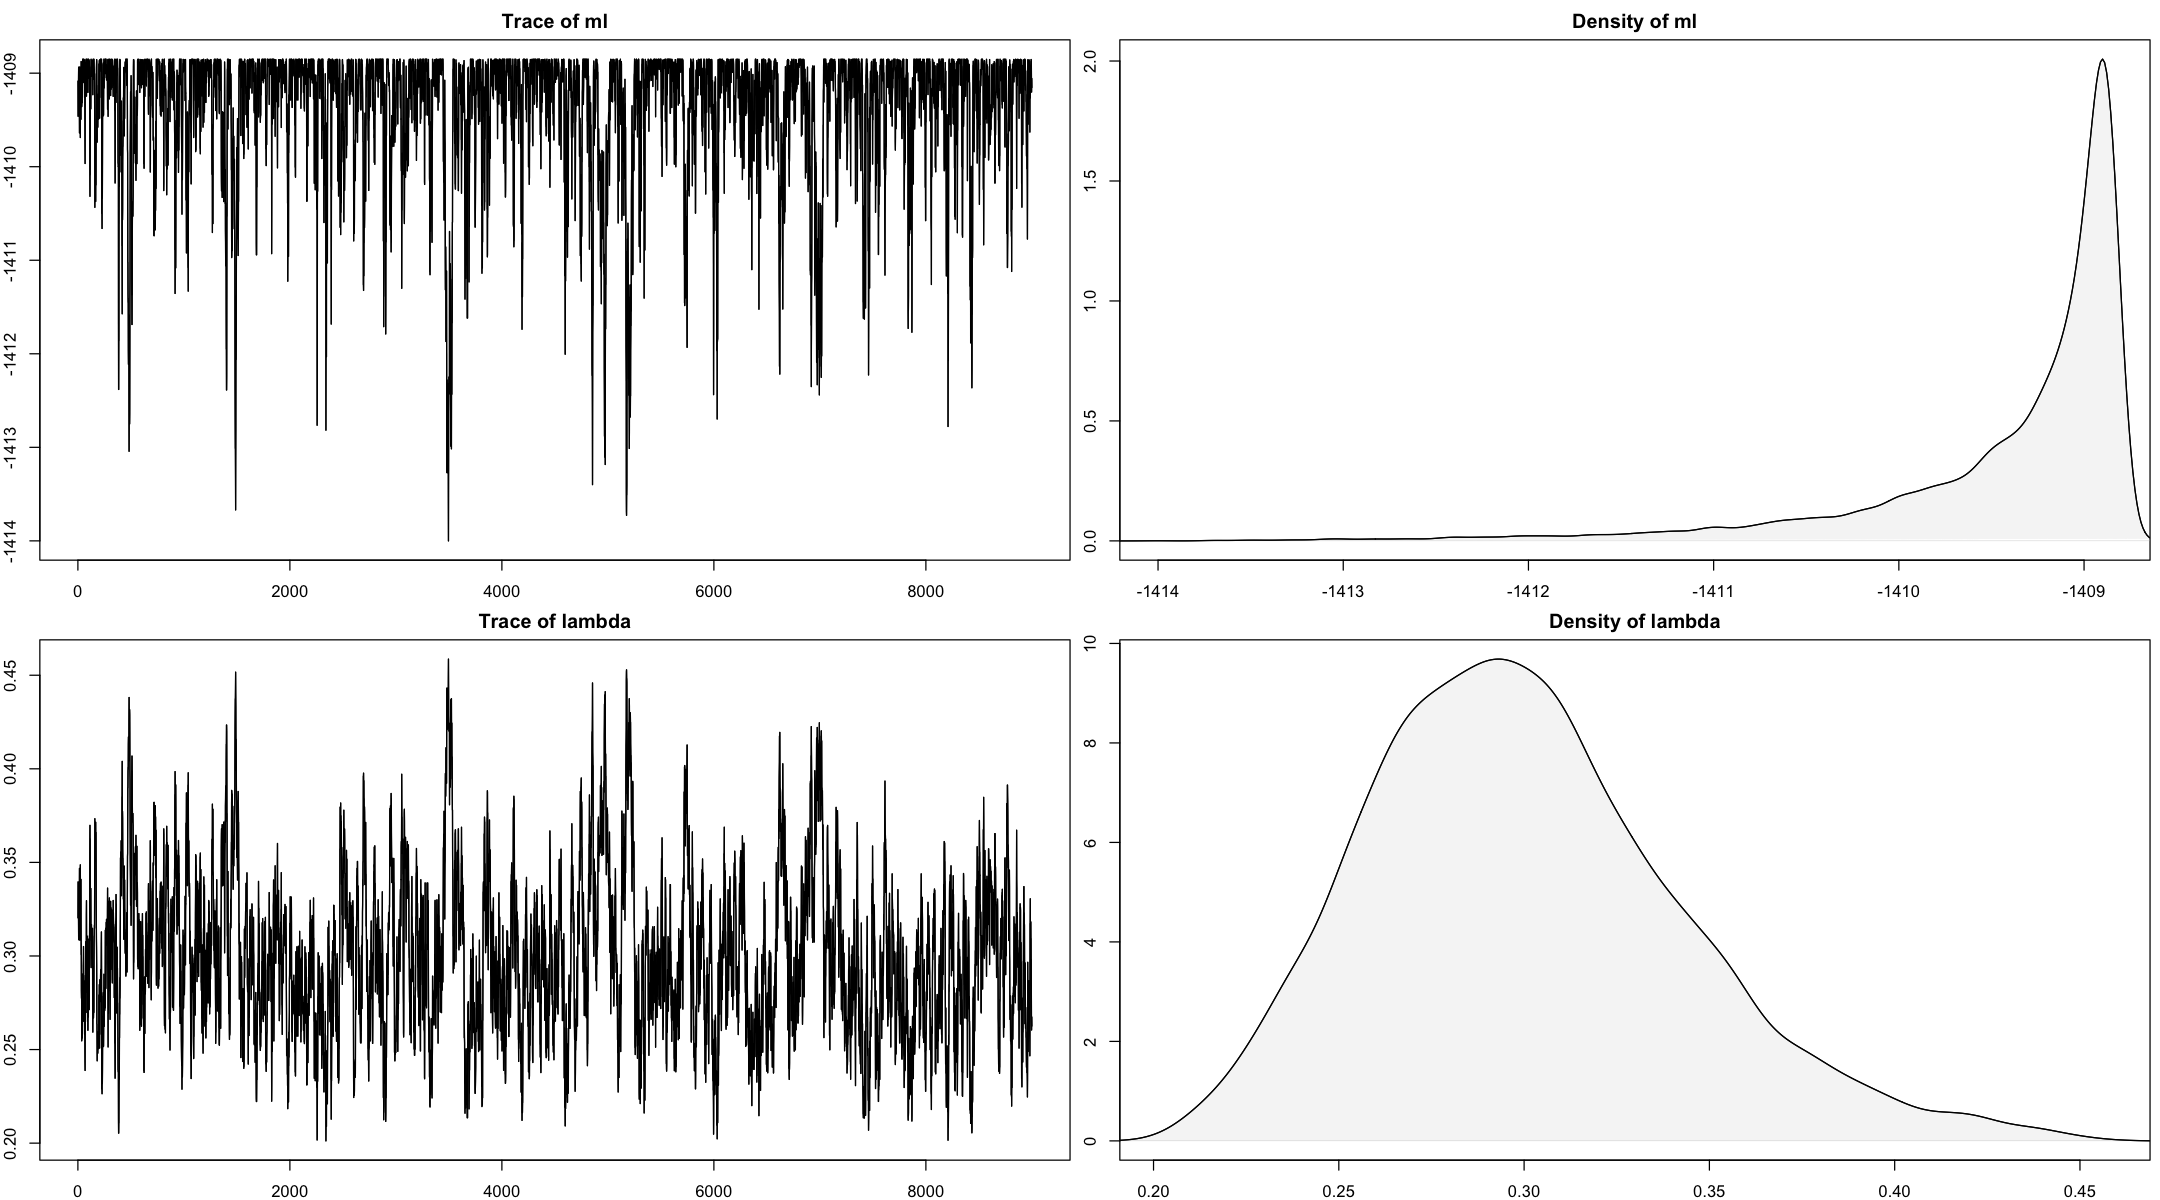

In [162]:
plot(bvar1)

good mixing of trace of lamda around 0.2-0.4 with highest density at 0.29. For Trace of ML there is no trend.

## IRF's

In [163]:
options(repr.plot.width = 8, repr.plot.height = 6)
irf(bvar1) <- irf(
  bvar1, 
  horizon = 20, 
  identification = TRUE, 
  conf_bands = 0.025
)

### IRF for oil shock

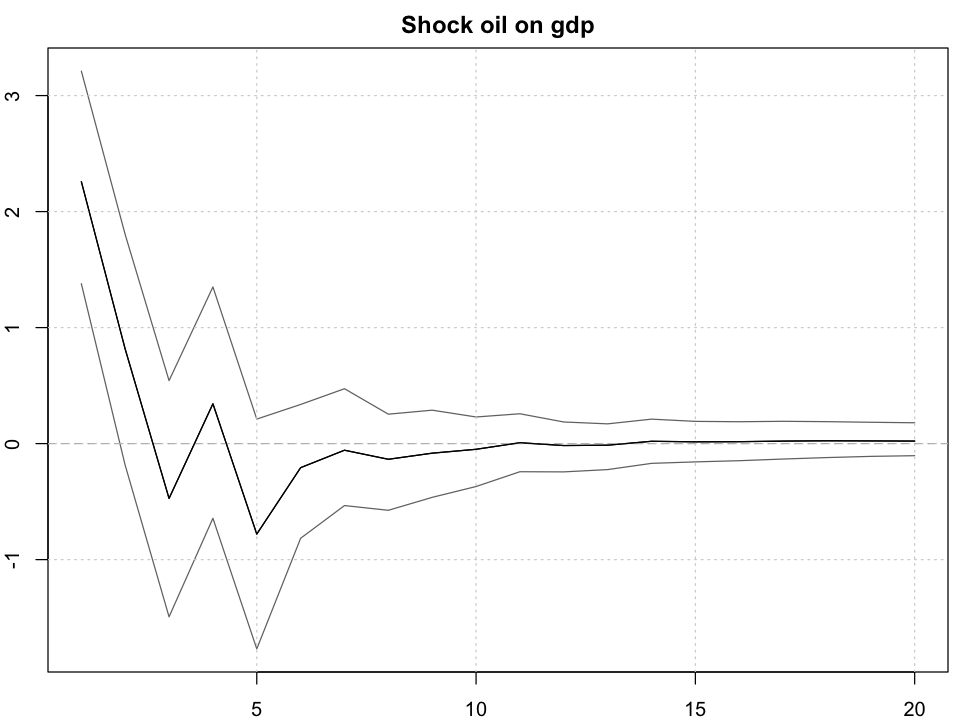

In [164]:
plot(irf(bvar1), vars_impulse = "oil", vars_response = "gdp")

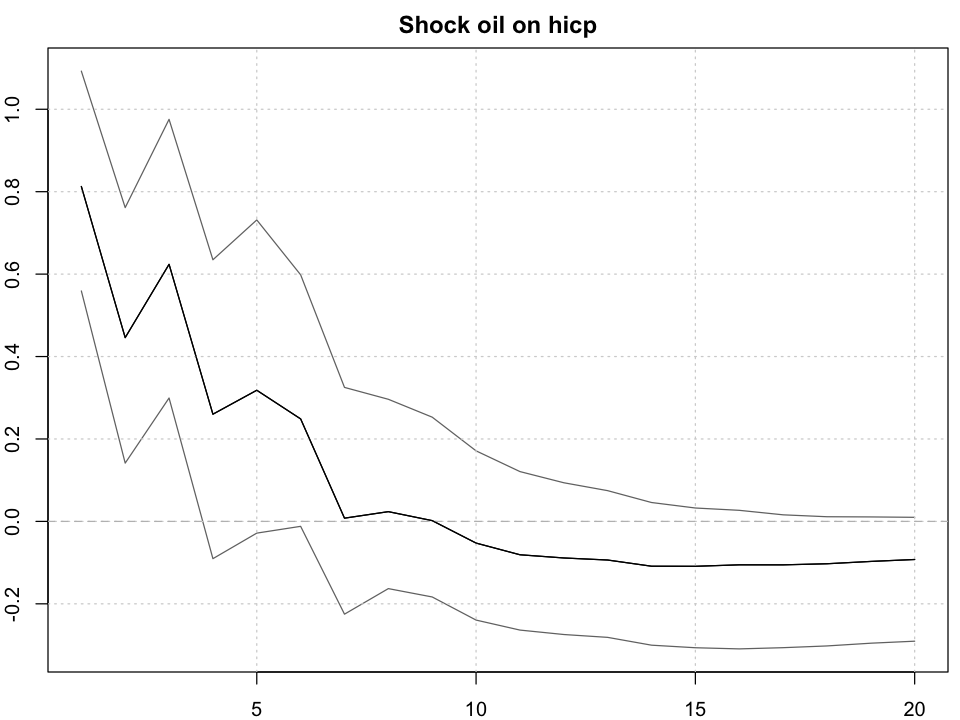

In [165]:
plot(irf(bvar1), vars_impulse = "oil", vars_response = "hicp")

n the BVAR model, we observe a trajectory similar to that of the Stage 2 VAR model. However, the evolution between the 5th and 10th quarters is smoother. Additionally, for the oil shock's impact on HICP, the 95% credible interval is more precise.

### IRF for interest rate shock

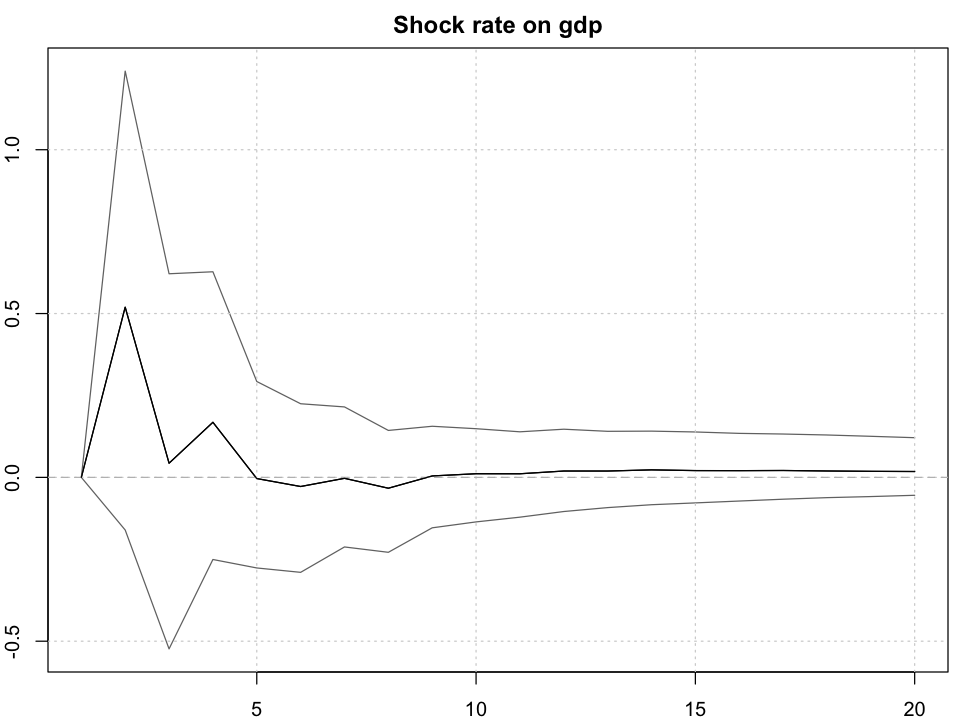

In [168]:
plot(irf(bvar1), vars_impulse = "rate", vars_response = "gdp")

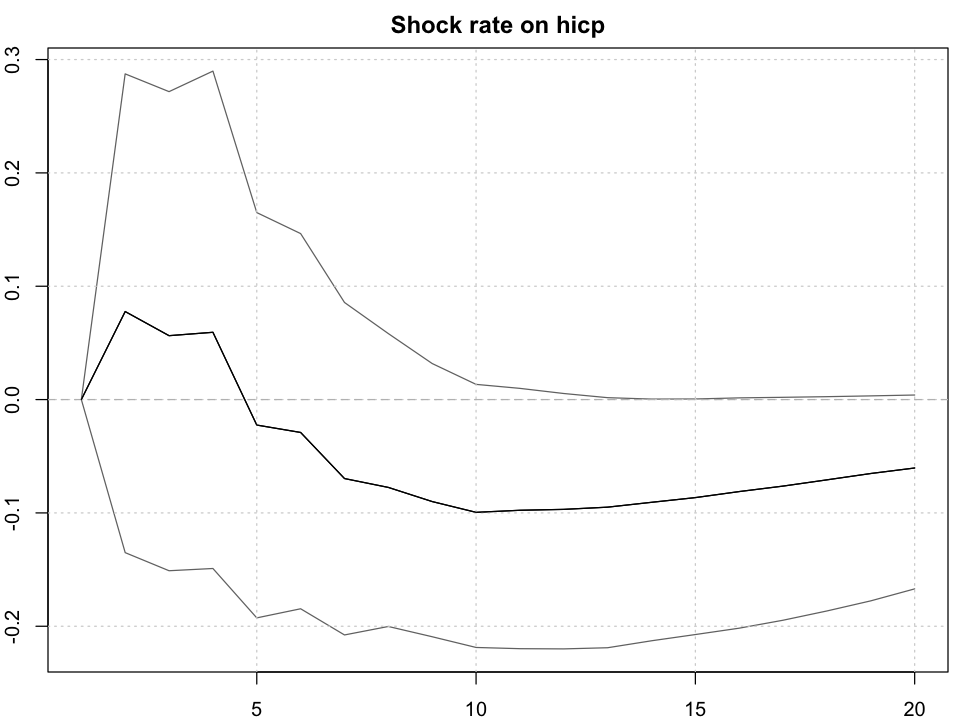

In [167]:
plot(irf(bvar1), vars_impulse = "rate", vars_response = "hicp")

Here the development of the shocks is also much smoother and overall trend remains similar. For the monetary policy shock to inflation, we can still see the price puzzle, and even the 95% probability interval did not fall below zero, whereas it did in the VAR.

Cannot plot area without quantiles.



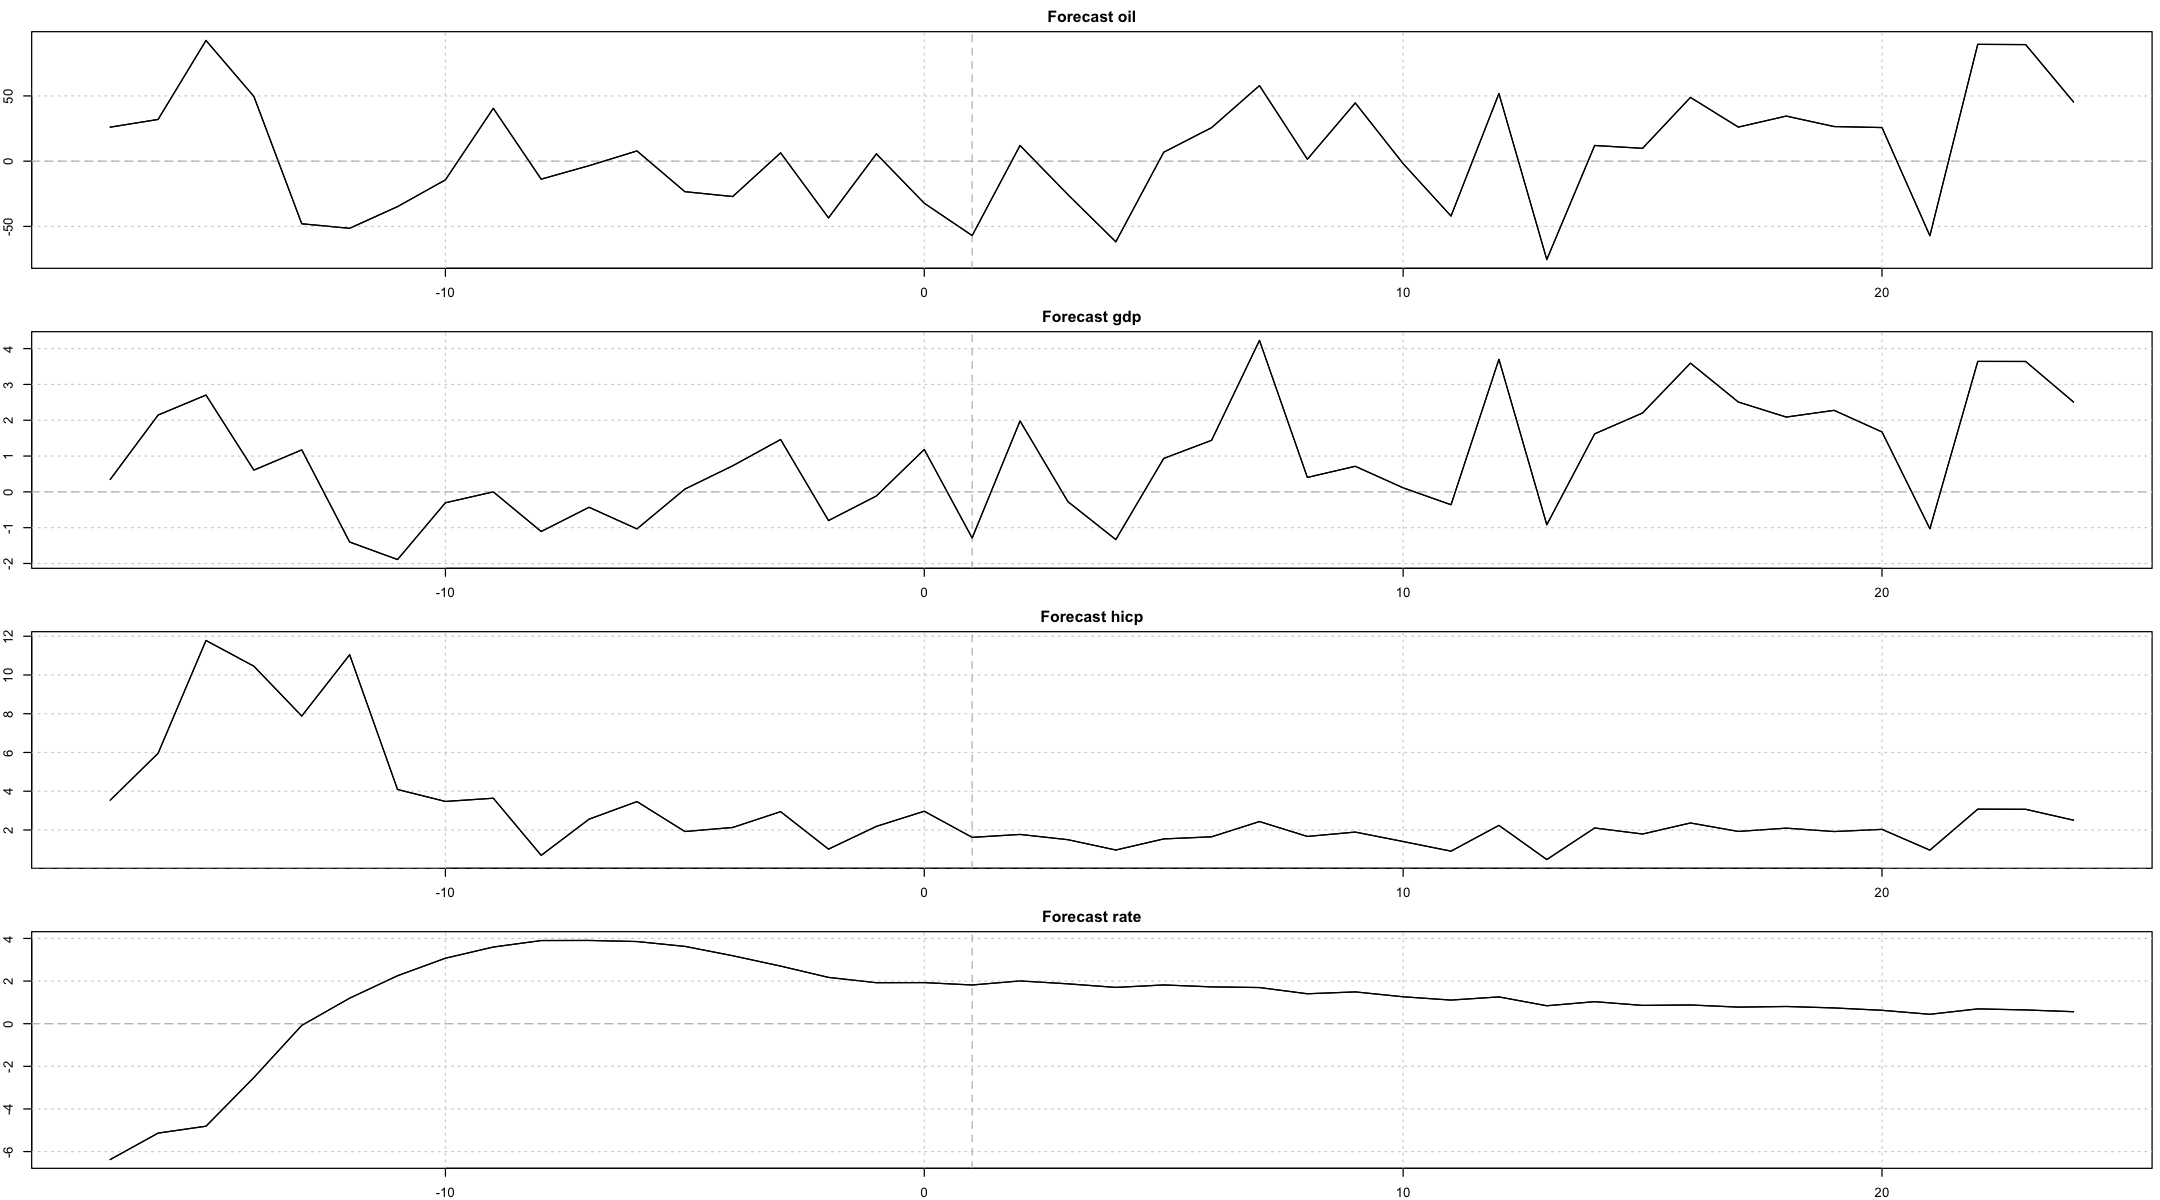

In [171]:
options(repr.plot.width = 18, repr.plot.height = 10)
pred_clean <- predict(bvar1, horizon = 24, conf_bands = c(0.5,0.5))
plot(pred_clean, area = TRUE, t_back = 18, draw_bands = TRUE)

For the VAR model from Stage 2, the forecast did not exhibit any substantial dynamics, showing mostly a standard trajectory reverting to the mean. I observe similar results here, even though the BVAR model is theoretically expected to be more precise.

# 4. BVAR with Sign restriction

In [172]:
# Columns: 1 = Demand shock, 2 = Oil/Supply shock, 3 = Monetary policy shock, 4 = Unidentified shock
sr <- matrix(c(
  # demand  oil_shock  monetary  shock4
      NA,       1,        NA,       NA,   # Row 1: oil 
       1,      -1,        -1,       NA,   # Row 2: gdp (economic growth)
       1,       1,        -1,       NA,   # Row 3: hicp (inflation)
       1,       1,         1,       NA    # Row 4: rate (interest rate)
), nrow = 4, byrow = TRUE)

print(sr)

     [,1] [,2] [,3] [,4]
[1,]   NA    1   NA   NA
[2,]    1   -1   -1   NA
[3,]    1    1   -1   NA
[4,]    1    1    1   NA


In [175]:
opt_signs <- bv_irf(horizon = 20, fevd = TRUE, identification = TRUE, sign_restr = sr)
print(opt_signs)

Object with settings for computing impulse responses.
Horizon: 20
Identification: Sign restrictions
Chosen restrictions:
			Shock to
			 Var1	 Var2	 Var3	 Var4	 
Response of	Var1	 NA	 +	 NA	 NA	

		Var2	 +	 -	 -	 NA	

		Var3	 +	 +	 -	 NA	

		Var4	 +	 +	 +	 NA	
FEVD: TRUE


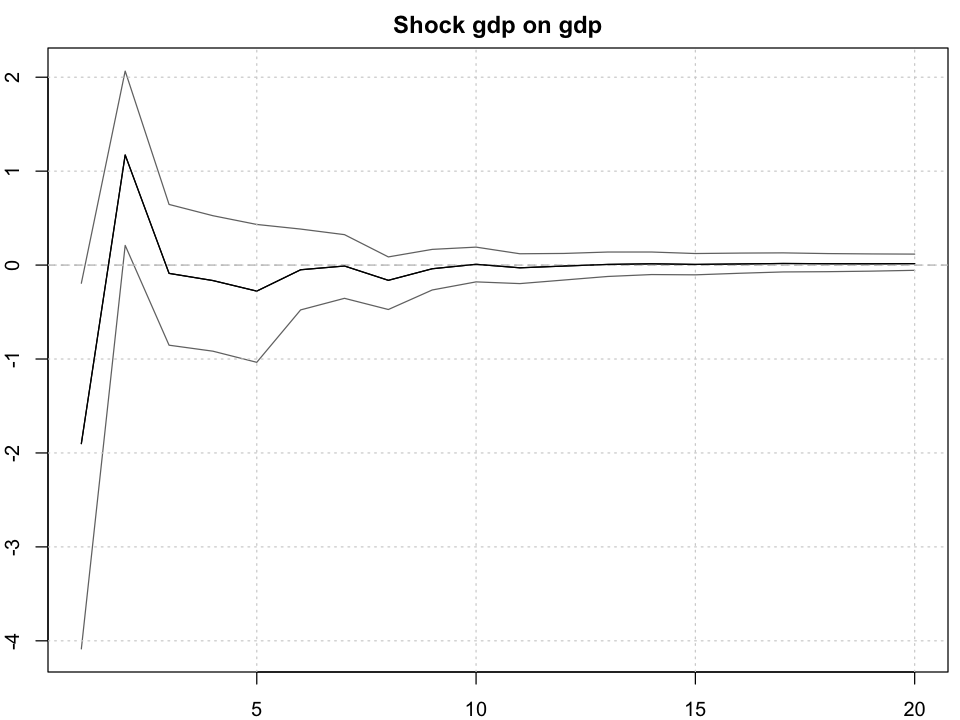

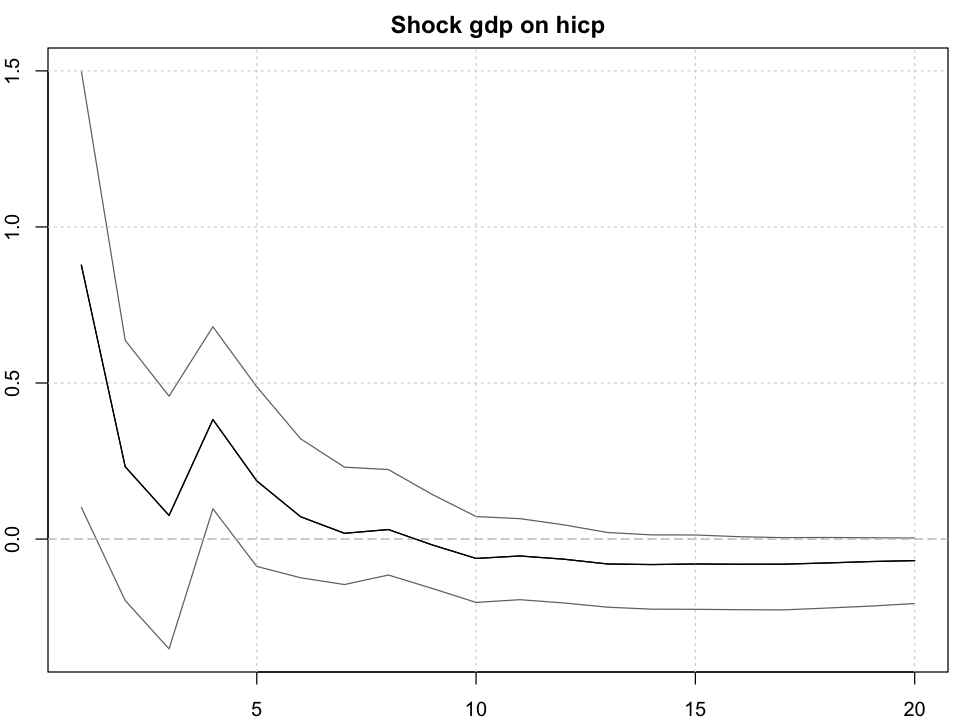

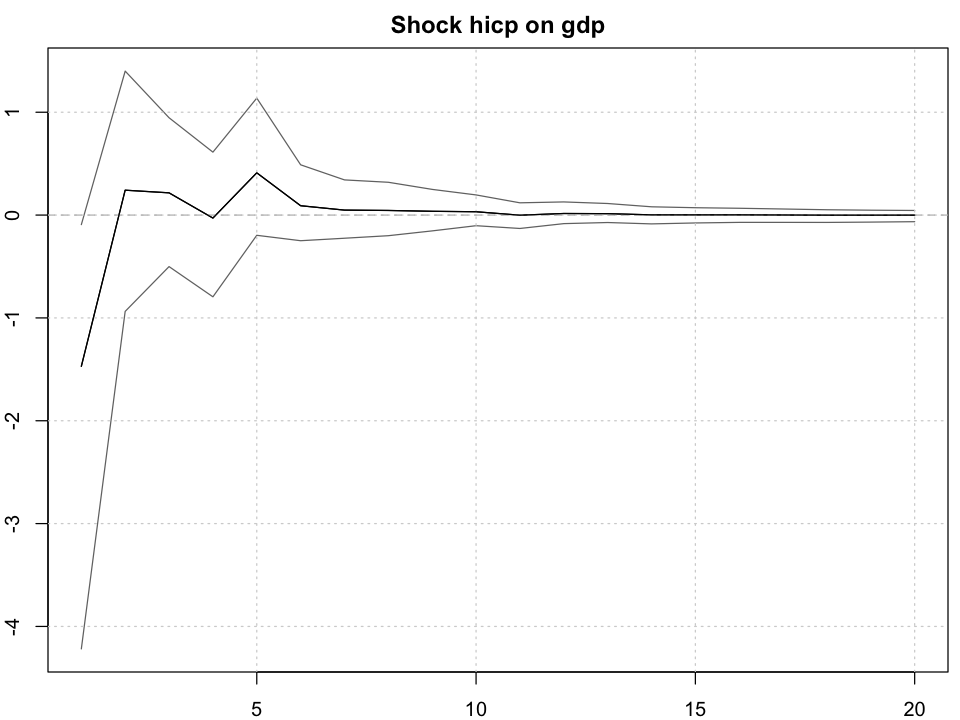

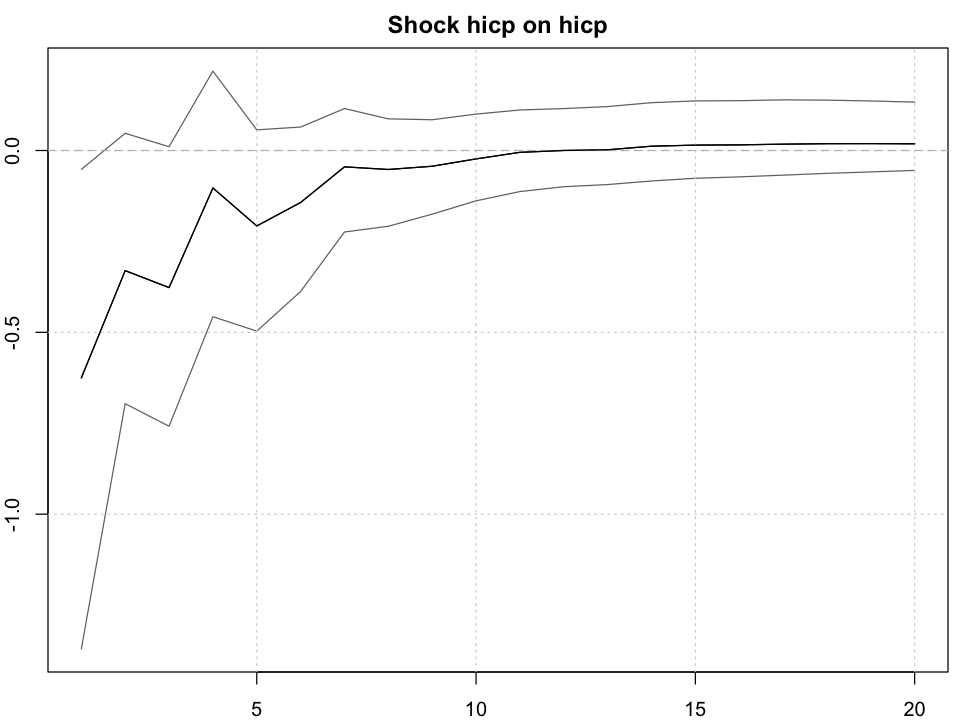

In [177]:
irf(bvar1) <- irf(
  bvar1,
  opt_signs,
  conf_bands = c(0.05),
  verbose = FALSE)

options(repr.plot.width = 8, repr.plot.height = 6)
# 2 column for oil shock
plot(irf(bvar1), vars_impulse = 2, vars_response = "gdp")
plot(irf(bvar1), vars_impulse = 2, vars_response = "hicp")

# 3th column for monetary shock
plot(irf(bvar1), vars_impulse = 3, vars_response = "gdp")
plot(irf(bvar1), vars_impulse = 3, vars_response = "hicp")

As shown in the first figure (response of GDP to an oil price shock), the standard VAR model yielded a counterintuitively positive effect. By imposing sign restrictions, we can see that the effect is now negative, although it is not statistically significant.

The last figure displays the effect of an interest rate shock on inflation. Since we imposed a negative sign restriction, the price puzzle has disappeared; however, the response is not statistically significant.

## Part III. Local projections and high-frequency identification

# 5. Local projection

In [179]:
vardata1_df2 <- data_bvar[c(-1)]

[[1]]
NULL


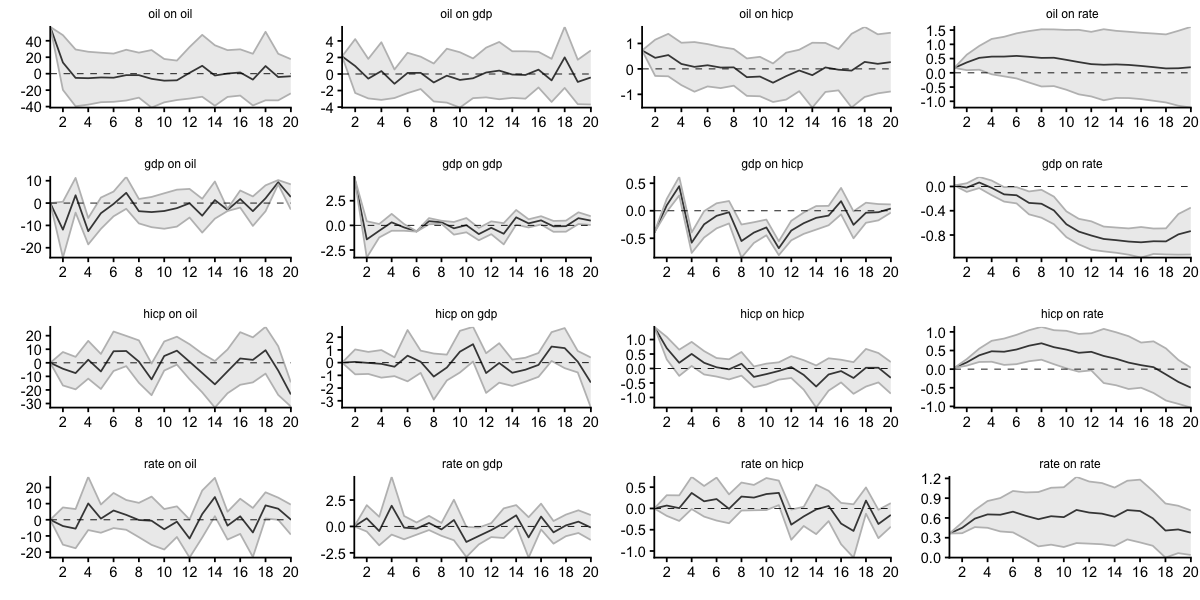

In [181]:
lp_var1 <- lp_lin(vardata1_df2, lags_endog_lin = 6, trend = 0, shock_type = 0, confint = 1.96, hor = 20)
plot(lp_var1)

At the beginning of the oil shock's impact on GDP and HICP, we observe the same initial trajectory (a positive effect) as in the VAR model. However, at longer horizons, the confidence intervals become substantially wider and volatile. For the monetary policy shock, the price puzzle is also present, but it is much more prolonged, lasting up to 12 quarters.

# 6. LP-IV

### MP shock with  high-frequency series (LP)
I'm using  Local projection with exogenous high-frequency monetary policy shock

In [200]:
path_raw <- read_xlsx("path_factor.xlsx")
path_q <- path_raw %>%
  mutate(quarter = floor_date(as.Date(time), "quarter")) %>%
  group_by(quarter) %>%
  summarise(path = sum(path, na.rm = TRUE))


path_aligned <- data_bvar %>%
  dplyr::select(date) %>% 
  left_join(path_q, by = c("date" = "quarter")) %>%
  mutate(path = ifelse(is.na(path), 0, path))

mpshock_df2 <- as.data.frame(path_aligned$path)
colnames(mpshock_df2) <- "path_shock"

[[1]]
NULL


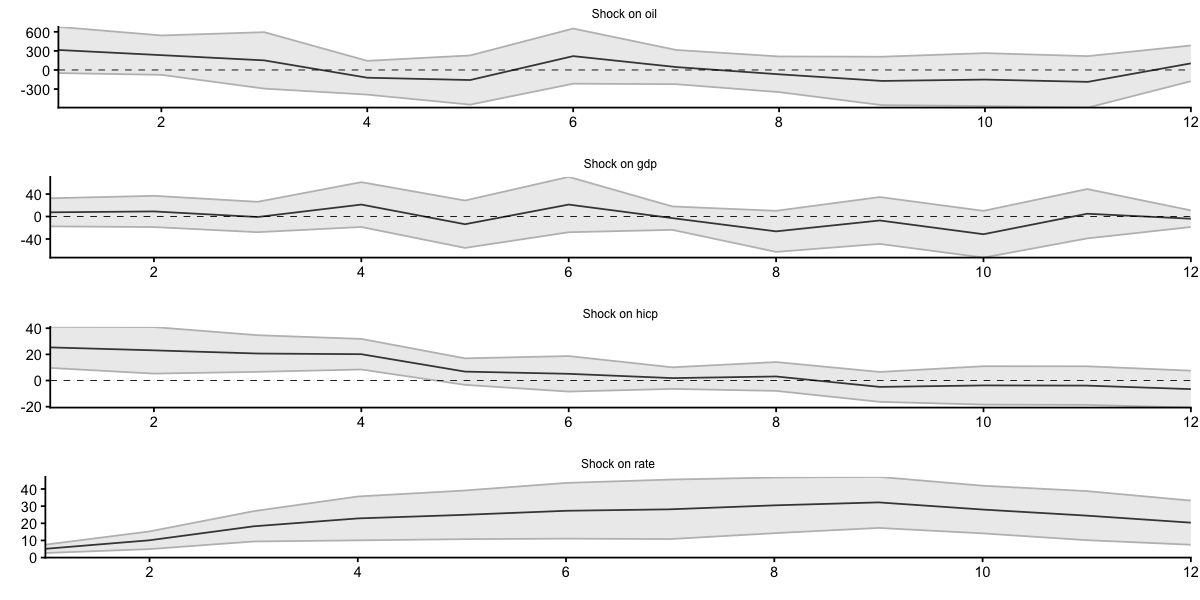

In [202]:
lp_var2_id <- lp_lin_iv(vardata1_df2, shock = mpshock_df2, lags_endog_lin = 4, trend = 0, confint = 1.96, hor = 12)
plot(lp_var2_id)

In [195]:
predict(model2, n.ahead = 12, ci = 0.95)

$oil
            fcst     lower    upper       CI
 [1,] -19.292612 -142.4523 103.8670 123.1596
 [2,]   1.632895 -125.6861 128.9518 127.3190
 [3,]   2.958282 -125.8146 131.7312 128.7729
 [4,]   1.507291 -127.8294 130.8440 129.3367
 [5,]   2.971167 -126.7948 132.7371 129.7659
 [6,]   3.047987 -126.8154 132.9114 129.8634
 [7,]   3.219293 -126.7045 133.1431 129.9238
 [8,]   3.497805 -126.4543 133.4499 129.9521
 [9,]   3.566192 -126.3960 133.5284 129.9622
[10,]   3.659171 -126.3080 133.6264 129.9672
[11,]   3.719573 -126.2492 133.6883 129.9688
[12,]   3.742370 -126.2268 133.7115 129.9691

$gdp
            fcst     lower    upper       CI
 [1,] 0.09318988 -10.84281 11.02919 10.93600
 [2,] 0.49741476 -11.00577 12.00060 11.50319
 [3,] 1.35817836 -10.20634 12.92269 11.56452
 [4,] 1.03366338 -10.55789 12.62522 11.59156
 [5,] 1.05429531 -10.55703 12.66562 11.61133
 [6,] 1.11258187 -10.50151 12.72667 11.61409
 [7,] 1.08225357 -10.53217 12.69668 11.61443
 [8,] 1.10259116 -10.51272 12.71790 11.61531

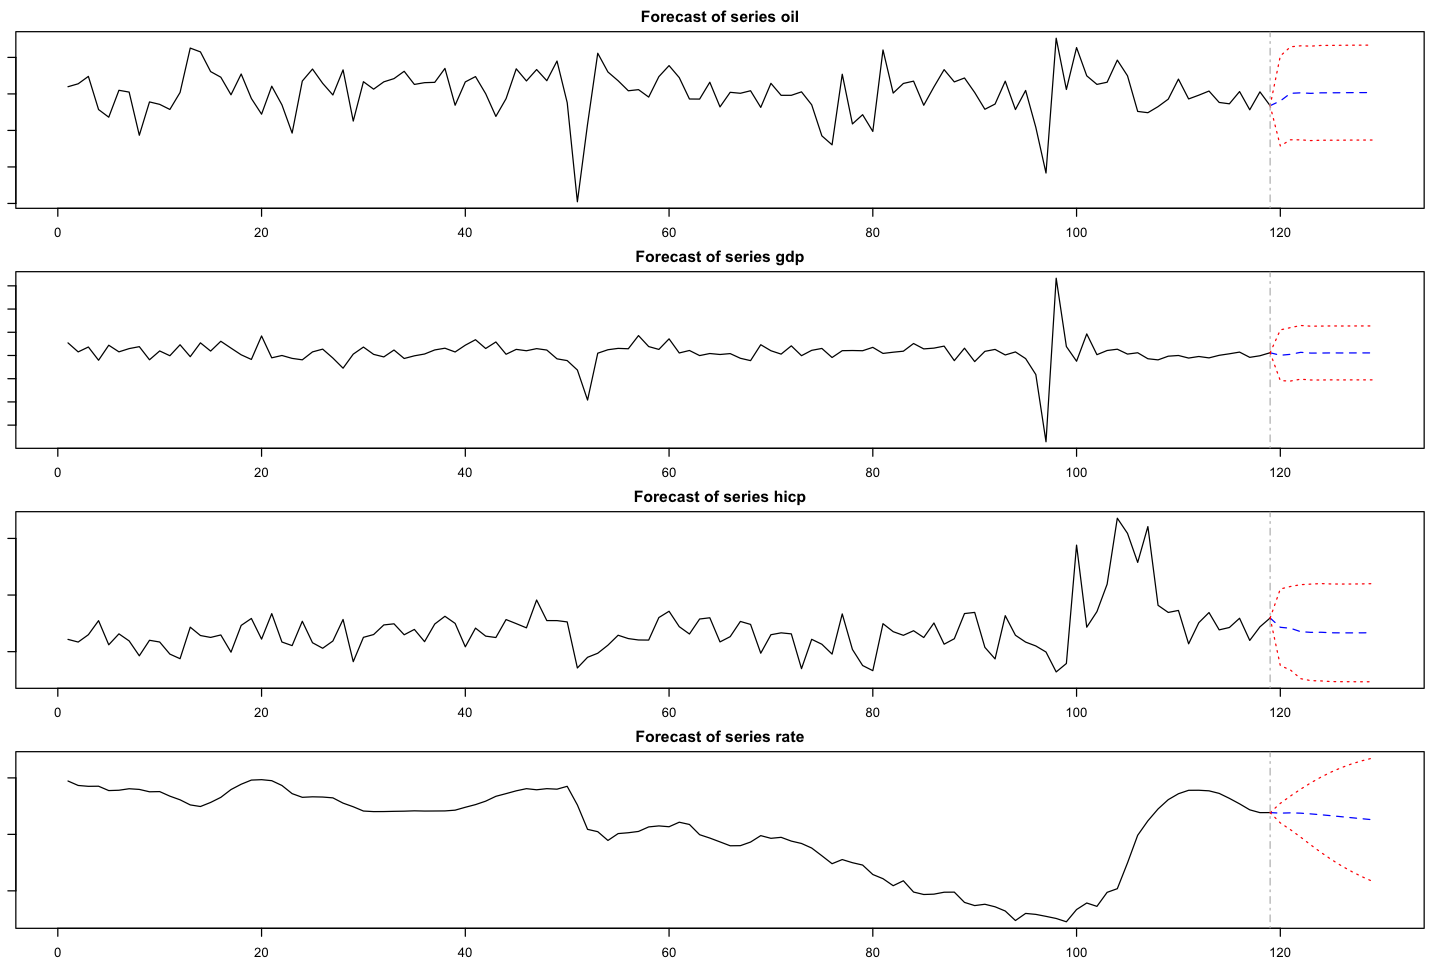

In [196]:
par(mar = c(2, 1, 2, 1))
plot(predict(model2))

Theoretically, the LP-IV approach is expected to provide the most realistic results. The results show no statistically significant response of GDP to the monetary policy shock. Additionally, the initial response of inflation is significantly positive, highlighting the persistence of the price puzzle even when using high-frequency identification.

Overall, I would choose the SVAR model despite the presence of the price puzzle (as opposed to the sign-restricted BVAR model). However, this may reflect reality, as it could signify a strong central bank information effect, where markets infer that the ECB possesses private information, thus driving up inflation expectations.